# Projet 4 – Analyse des causes de démission chez TechNova Partners

In [76]:
# ============================================================
# IMPORTS : on charge toutes les librairies du projet
# ============================================================
import pandas as pd                # tableaux de données (DataFrame)
import numpy as np                 # calculs numériques
import matplotlib.pyplot as plt    # graphiques de base
import seaborn as sns              # graphiques statistiques plus jolis
import sklearn                     # machine learning
import imblearn                    # gestion du déséquilibre des classes
import shap                        # interprétation du modèle

## 1. Chargement et découverte des données

In [77]:
# Chaque fichier vient d'un système différent de TechNova :
#  - SIRH    : infos RH (poste, âge, salaire, ancienneté...)
#  - EVAL    : évaluations annuelles et satisfaction
#  - SONDAGE : sondage bien-être + la cible "a quitté l'entreprise"
df_sirh = pd.read_csv("data/extrait_sirh.csv")
df_eval = pd.read_csv("data/extrait_eval.csv")
df_sondage = pd.read_csv("data/extrait_sondage.csv")

### 1.1 Découverte du fichier SIRH

In [78]:
# 1) Les 5 premières lignes
display(df_sirh.head())

# 2) Le type de chaque colonne et le nombre de valeurs non vides
df_sirh.info()

# 3) Les statistiques des colonnes numériques (moyenne, min, max...)
display(df_sirh.describe())

# 4) Le nombre de valeurs différentes par colonne
display(df_sirh.nunique())

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id_employee                     1470 non-null   int64
 1   age                             1470 non-null   int64
 2   genre                           1470 non-null   str  
 3   revenu_mensuel                  1470 non-null   int64
 4   statut_marital                  1470 non-null   str  
 5   departement                     1470 non-null   str  
 6   poste                           1470 non-null   str  
 7   nombre_experiences_precedentes  1470 non-null   int64
 8   nombre_heures_travailless       1470 non-null   int64
 9   annee_experience_totale         1470 non-null   int64
 10  annees_dans_l_entreprise        1470 non-null   int64
 11  annees_dans_le_poste_actuel     1470 non-null   int64
dtypes: int64(8), str(4)
memory usage: 137.9 KB


,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000
mean,1024.865306,36.923810,6502.931293,2.693197,80.0,11.279592,7.008163,4.229252
std,602.024335,9.135373,4707.956783,2.498009,0.0,7.780782,6.126525,3.623137
min,1.000000,18.000000,1009.000000,0.000000,80.0,0.000000,0.000000,0.000000
25%,491.250000,30.000000,2911.000000,1.000000,80.0,6.000000,3.000000,2.000000
50%,1020.500000,36.000000,4919.000000,2.000000,80.0,10.000000,5.000000,3.000000
75%,1555.750000,43.000000,8379.000000,4.000000,80.0,15.000000,9.000000,7.000000
max,2068.000000,60.000000,19999.000000,9.000000,80.0,40.000000,40.000000,18.000000


id_employee                       1470
age                                 43
genre                                2
revenu_mensuel                    1349
statut_marital                       3
departement                          3
poste                                9
nombre_experiences_precedentes      10
nombre_heures_travailless            1
annee_experience_totale             40
annees_dans_l_entreprise            37
annees_dans_le_poste_actuel         19
dtype: int64

#### **Observations fichier SIRH**
- Pas de valeurs manquantes ni de doublons
- `nombre_heures_travailless` vaut 80 pour tout le monde,colonne inutile à supprimer
- Salaire max à 19 999 € : valeur très haute, à vérifier

In [79]:
# Vérification du salaire max à 19999
# Salaire min / médian / max par poste
# A priori, pas une abbération
display(df_sirh.groupby("poste")["revenu_mensuel"].agg(["min", "median", "max"]).sort_values("median"))

,min,median,max
poste,,,
Représentant Commercial,1052,2579.0,6632
Consultant,1102,2886.0,7403
Assistant de Direction,1009,2887.5,9724
Ressources Humaines,1555,3093.0,10725
Cadre Commercial,4001,6231.0,13872
Tech Lead,4011,6447.0,13973
Manager,4000,6811.0,13966
Directeur Technique,11031,16510.0,19973
Senior Manager,11244,17454.5,19999


Le 19 999 € concerne un Senior Manager, poste dont la médiane est d'environ 17 500 € : valeur extrême mais légitime, **on la conserve**.

### 1.2 Découverte du fichier EVAL

In [80]:
# 1) Les 5 premières lignes
display(df_eval.head())

# 2) Le type de chaque colonne et le nombre de valeurs non vides
df_eval.info()

# 3) Les statistiques des colonnes numériques (moyenne, min, max...)
display(df_eval.describe())

# 4) Le nombre de valeurs différentes par colonne
display(df_eval.nunique())

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   satisfaction_employee_environnement        1470 non-null   int64
 1   note_evaluation_precedente                 1470 non-null   int64
 2   niveau_hierarchique_poste                  1470 non-null   int64
 3   satisfaction_employee_nature_travail       1470 non-null   int64
 4   satisfaction_employee_equipe               1470 non-null   int64
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64
 6   eval_number                                1470 non-null   str  
 7   note_evaluation_actuelle                   1470 non-null   int64
 8   heure_supplementaires                      1470 non-null   str  
 9   augementation_salaire_precedente           1470 non-null   str  
dtypes: int64(7), str(3)
memory usage: 115.0 KB


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.721769,2.729932,2.063946,2.728571,2.712245,2.761224,3.153741
std,1.093082,0.711561,1.106940,1.102846,1.081209,0.706476,0.360824
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000
50%,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,4.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000
max,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000


satisfaction_employee_environnement             4
note_evaluation_precedente                      4
niveau_hierarchique_poste                       5
satisfaction_employee_nature_travail            4
satisfaction_employee_equipe                    4
satisfaction_employee_equilibre_pro_perso       4
eval_number                                  1470
note_evaluation_actuelle                        2
heure_supplementaires                           2
augementation_salaire_precedente               15
dtype: int64

#### **Observations fichier EVAL**
- Pas de valeurs manquantes ni de doublons
- `augementation_salaire_precedente` : nombre stocké en texte à convertir (+ faute dans le nom colonne)
- `heure_supplementaires` : Oui/Non à convertir en binaire
- `eval_number` : identifiant au format "E_1" bonne piste pour jointure

### 1.3 Découverte du fichier SONDAGE

In [81]:
# 1) Les 5 premières lignes
display(df_sondage.head())

# 2) Le type de chaque colonne et le nombre de valeurs non vides
df_sondage.info()

# 3) Les statistiques des colonnes numériques (moyenne, min, max...)
display(df_sondage.describe())

# 4) Le nombre de valeurs différentes par colonne
display(df_sondage.nunique())

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   a_quitte_l_entreprise                1470 non-null   str  
 1   nombre_participation_pee             1470 non-null   int64
 2   nb_formations_suivies                1470 non-null   int64
 3   nombre_employee_sous_responsabilite  1470 non-null   int64
 4   code_sondage                         1470 non-null   int64
 5   distance_domicile_travail            1470 non-null   int64
 6   niveau_education                     1470 non-null   int64
 7   domaine_etude                        1470 non-null   str  
 8   ayant_enfants                        1470 non-null   str  
 9   frequence_deplacement                1470 non-null   str  
 10  annees_depuis_la_derniere_promotion  1470 non-null   int64
 11  annes_sous_responsable_actuel        1470 non-null   int64
dtypes: 

,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.793878,2.799320,1.0,1024.865306,9.192517,2.912925,2.187755,4.123129
std,0.852077,1.289271,0.0,602.024335,8.106864,1.024165,3.222430,3.568136
min,0.000000,0.000000,1.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,1.0,491.250000,2.000000,2.000000,0.000000,2.000000
50%,1.000000,3.000000,1.0,1020.500000,7.000000,3.000000,1.000000,3.000000
75%,1.000000,3.000000,1.0,1555.750000,14.000000,4.000000,3.000000,7.000000
max,3.000000,6.000000,1.0,2068.000000,29.000000,5.000000,15.000000,17.000000


a_quitte_l_entreprise                     2
nombre_participation_pee                  4
nb_formations_suivies                     7
nombre_employee_sous_responsabilite       1
code_sondage                           1470
distance_domicile_travail                29
niveau_education                          5
domaine_etude                             6
ayant_enfants                             1
frequence_deplacement                     3
annees_depuis_la_derniere_promotion      16
annes_sous_responsable_actuel            18
dtype: int64

#### **Observations fichier SONDAGE**

- Pas de valeurs manquantes ni de doublons
- `a_quitte_l_entreprise` : **variable cible** (Oui/Non), à convertir en 1/0
- `code_sondage` : 1 470 valeurs uniques, semble correspondre à `id_employee` du SIRH, **à vérifier** avant la jointure
- Colonnes constantes (une seule valeur pour tous) donc à supprimer :
  - `nombre_employee_sous_responsabilite` (toujours 1)
  - `ayant_enfants` (toujours "Y")
- `annes_sous_responsable_actuel` : faute dans le nom, à voir si on corrige

**Pistes pour préparation modèle**
- `domaine_etude` : texte sans ordre → encodage one-hot
- `frequence_deplacement` : texte avec un ordre naturel (Aucun < Occasionnel < Fréquent), encodage à choisir
- `distance_domicile_travail` : découpage en tranches éventuel

In [82]:
# Les identifiants du sondage sont-ils exactement les mêmes que ceux du SIRH ?
# set() = ensemble de valeurs, l'ordre n'a pas d'importance
print(set(df_sondage["code_sondage"]) == set(df_sirh["id_employee"]))

True


→ Vérification : les 1 470 valeurs de `code_sondage` sont exactement les mêmes que celles de `id_employee` (SIRH).
**`code_sondage` servira de clé de jointure.**

## 2. Nettoyage des données

**Plan de nettoyage**

1. **Harmoniser les clés de jointure** : `id_employee` (SIRH), `eval_number` au format "E_1" (EVAL), `code_sondage` (SONDAGE)
2. **Supprimer les colonnes constantes** : `nombre_heures_travailless`, `nombre_employee_sous_responsabilite`, `ayant_enfants`
3. **Convertir les textes numériques** : `augementation_salaire_precedente` ("11 %" → 11)
4. **Convertir les Oui/Non en 1/0** : `heure_supplementaires`, `a_quitte_l_entreprise`
5. **Corriger les fautes dans les noms de colonnes**
6. **Joindre les 3 fichiers** en un DataFrame central

### 2.1 **Harmoniser les clés de jointure**

In [83]:
# ------------------------------------------------------------
# EVAL : "E_1" -> 1
# ------------------------------------------------------------
# .apply() applique une petite fonction à chaque valeur de la colonne.
# lambda x: ... = fonction "jetable" : pour chaque valeur x,
#   1) on retire le texte "E_"   -> "E_12" devient "12"
#   2) on convertit en entier    -> "12" devient 12
#   3) on mets le resultat transformé dans une nouvelle colonne "id_employee"
df_eval["id_employee"] = df_eval["eval_number"].apply(lambda x: int(x.replace("E_", "")))

# ------------------------------------------------------------
# SONDAGE : déjà un nombre, on renomme simplement la colonne
# ------------------------------------------------------------
df_sondage = df_sondage.rename(columns={"code_sondage": "id_employee"})

# ------------------------------------------------------------
# Vérification : les 3 fichiers ont-ils maintenant les mêmes identifiants ?
# ------------------------------------------------------------
print("id_employee de EVAL = id_employee de SIRH :", set(df_eval["id_employee"]) == set(df_sirh["id_employee"]))
print("id_employee de SONDAGE = id_employee de SIRH :", set(df_sondage["id_employee"]) == set(df_sirh["id_employee"]))

id_employee de EVAL = id_employee de SIRH : True
id_employee de SONDAGE = id_employee de SIRH : True


Les 3 fichiers partagent maintenant une colonne `id_employee` avec exactement les mêmes 1 470 valeurs.
**Les clés de jointure sont harmonisées.**

### 2.2 **Supprimer les colonnes qui ne contiennent qu'une valeur unique**

In [84]:
# ------------------------------------------------------------
# Détection automatique des colonnes constantes
# ------------------------------------------------------------
# Une colonne constante = une seule valeur pour tous les employés
# -> elle ne permet de distinguer personne, donc inutile pour l'analyse et le modèle
for nom, df_fichier in [("SIRH", df_sirh), ("EVAL", df_eval), ("SONDAGE", df_sondage)]:
    # nunique() compte les valeurs différentes ; on garde les colonnes où ce nombre vaut 1
    colonnes_constantes = [col for col in df_fichier.columns if df_fichier[col].nunique() == 1]
    print(f"{nom} : {colonnes_constantes}")

SIRH : ['nombre_heures_travailless']
EVAL : []
SONDAGE : ['nombre_employee_sous_responsabilite', 'ayant_enfants']


In [85]:
# ------------------------------------------------------------
# Fonction : détection et suppression des colonnes constantes
# ------------------------------------------------------------
def supprimer_colonnes_constantes(df, nom):
    """Détecte les colonnes à valeur unique, les affiche, puis les supprime."""
    # 1) Détection : colonnes qui n'ont qu'une seule valeur différente
    colonnes_constantes = [col for col in df.columns if df[col].nunique() == 1]
    # 2) Affichage : on garde une trace de ce qui est supprimé
    print(f"{nom} : suppression de {colonnes_constantes}")
    # 3) Suppression et renvoi du DataFrame nettoyé
    return df.drop(columns=colonnes_constantes)

# On applique la fonction aux 3 fichiers
df_sirh = supprimer_colonnes_constantes(df_sirh, "SIRH")
df_eval = supprimer_colonnes_constantes(df_eval, "EVAL")
df_sondage = supprimer_colonnes_constantes(df_sondage, "SONDAGE")

# Vérification : nombre de lignes et de colonnes après suppression
print("\nSIRH :", df_sirh.shape)
print("EVAL :", df_eval.shape)
print("SONDAGE :", df_sondage.shape)

SIRH : suppression de ['nombre_heures_travailless']
EVAL : suppression de []
SONDAGE : suppression de ['nombre_employee_sous_responsabilite', 'ayant_enfants']

SIRH : (1470, 11)
EVAL : (1470, 11)
SONDAGE : (1470, 10)


### 2.3 **Convertir les textes numériques**

In [86]:
# ------------------------------------------------------------
# "11 %" -> 11
# ------------------------------------------------------------
# Pour chaque valeur x :
#   str(x)            -> on s'assure que c'est du texte (évite une erreur si on relance la cellule)
#   .replace("%", "") -> on retire le symbole %      : "11 %" devient "11 "
#   .strip()          -> on retire les espaces autour : "11 " devient "11"
#   int(...)          -> on convertit en nombre entier : "11" devient 11
df_eval["augementation_salaire_precedente"] = df_eval["augementation_salaire_precedente"].apply(
    lambda x: int(str(x).replace("%", "").strip())
)

# Vérification 1 : le type doit maintenant être un nombre (int64) et non plus du texte
print("Type :", df_eval["augementation_salaire_precedente"].dtype)

# Vérification 2 : les statistiques s'affichent enfin, preuve que c'est un vrai nombre
display(df_eval["augementation_salaire_precedente"].describe())

Type : int64


count    1470.000000
mean       15.209524
std         3.659938
min        11.000000
25%        12.000000
50%        14.000000
75%        18.000000
max        25.000000
Name: augementation_salaire_precedente, dtype: float64

### 2.4 **Conversion des données Oui/Non en Binaire**

In [87]:
# ------------------------------------------------------------
# Fonction : convertit une valeur Oui/Non en 1/0
# ------------------------------------------------------------
def oui_non_en_binaire(valeur):
    """'Oui' -> 1, 'Non' -> 0, toute autre valeur est laissée telle quelle."""
    if valeur == "Oui":
        return 1
    if valeur == "Non":
        return 0
    return valeur  # déjà convertie (cellule relancée) ou valeur inattendue : on n'y touche pas

# Application aux 2 colonnes avec .apply()
df_eval["heure_supplementaires"] = df_eval["heure_supplementaires"].apply(oui_non_en_binaire)
df_sondage["a_quitte_l_entreprise"] = df_sondage["a_quitte_l_entreprise"].apply(oui_non_en_binaire)

# Vérification : combien de 1 et de 0 dans chaque colonne ?
display(df_eval["heure_supplementaires"].value_counts())
display(df_sondage["a_quitte_l_entreprise"].value_counts())

heure_supplementaires
0    1054
1     416
Name: count, dtype: int64

a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64

### 2.5 **Correction noms de colonnes pour affichage des données**

In [88]:
# ------------------------------------------------------------
# Correction des fautes de frappe dans les noms de colonnes
# ------------------------------------------------------------
# Rappel : "nombre_heures_travailless" a déjà été supprimée (colonne constante)
df_eval = df_eval.rename(columns={
    "augementation_salaire_precedente": "augmentation_salaire_precedente",
    "heure_supplementaires": "heures_supplementaires",
})
df_sondage = df_sondage.rename(columns={
    "annes_sous_responsable_actuel": "annees_sous_responsable_actuel",
})

# Vérification : on affiche les noms de colonnes
print("EVAL :", list(df_eval.columns))
print("SONDAGE :", list(df_sondage.columns))

EVAL : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heures_supplementaires', 'augmentation_salaire_precedente', 'id_employee']
SONDAGE : ['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'id_employee', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annees_sous_responsable_actuel']


### 2.6 **Jointure des trois fichiers**

In [89]:
# ------------------------------------------------------------
# JOINTURE : SIRH (référentiel) + EVAL + SONDAGE
# ------------------------------------------------------------
# how="left"          -> on part du SIRH et on garde tous ses employés
# on="id_employee"    -> la clé commune harmonisée à l'étape 2.1
# validate="1:1"      -> sécurité : pandas vérifie qu'un employé n'apparaît qu'une fois
#                        de chaque côté, sinon il affiche une erreur au lieu de dupliquer des lignes
df = (
    df_sirh
    .merge(df_eval.drop(columns=["eval_number"]), on="id_employee", how="left", validate="1:1") # Je drop "eval_number" car elle est redondante avec "id_employee"
    .merge(df_sondage, on="id_employee", how="left", validate="1:1")
)

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------
# 1) Nombre de lignes et de colonnes
#    attendu : 1470 lignes, 29 colonnes (11 SIRH + 10 EVAL + 10 SONDAGE - 2 clés en double)
print("Dimensions :", df.shape)

# 2) Aucune case vide ne doit être apparue avec la jointure
print("Valeurs manquantes :", df.isna().sum().sum())

# 3) Aperçu du DataFrame central
display(df.head())

Dimensions : (1470, 29)
Valeurs manquantes : 0


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,...,augmentation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annees_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,...,11,1,0,0,1,2,Infra & Cloud,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,...,23,0,1,3,8,1,Infra & Cloud,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,7,0,...,15,1,0,3,2,2,Autre,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,...,11,0,0,3,3,4,Infra & Cloud,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,6,2,...,12,0,1,3,2,1,Transformation Digitale,Occasionnel,2,2


**Bilan du nettoyage**
- 3 fichiers de 1 470 employés, sans valeurs manquantes ni doublons
- Clés harmonisées (`id_employee`) puis jointure *left* depuis le SIRH (référentiel des employés)
- 3 colonnes constantes supprimées, 1 pourcentage converti en nombre, 2 colonnes Oui/Non converties en 1/0, 3 noms corrigés
- **Résultat : un DataFrame central de 1 470 lignes × 29 colonnes, dont la cible `a_quitte_l_entreprise` (16 % de départs)**

## 3. Analyse exploratoire
### 3.1 La variable cible

,Effectif,Pourcentage (%)
a_quitte_l_entreprise,,
0,1233,83.9
1,237,16.1


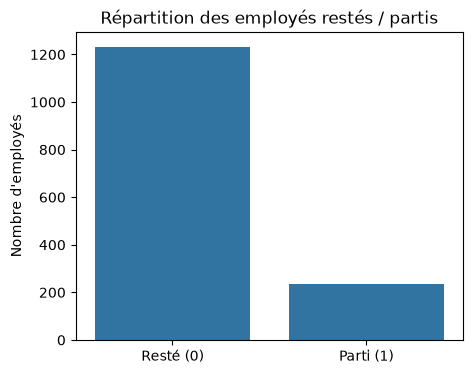

In [90]:
# ------------------------------------------------------------
# Combien d'employés sont partis ?
# ------------------------------------------------------------
# value_counts() compte les 0 et les 1 ; normalize=True donne des proportions
effectifs = df["a_quitte_l_entreprise"].value_counts()
proportions = df["a_quitte_l_entreprise"].value_counts(normalize=True) * 100
display(pd.DataFrame({"Effectif": effectifs, "Pourcentage (%)": proportions.round(1)}))

# ------------------------------------------------------------
# Diagramme en barres
# ------------------------------------------------------------
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="a_quitte_l_entreprise")
plt.xticks([0, 1], ["Resté (0)", "Parti (1)"])   # étiquettes lisibles au lieu de 0/1
plt.title("Répartition des employés restés / partis")
plt.xlabel("")
plt.ylabel("Nombre d'employés")
plt.show()

### 3.2 Comparaison partants / restants

In [91]:
# ------------------------------------------------------------
# Moyenne de chaque variable numérique, selon que l'employé est parti ou non
# ------------------------------------------------------------
# 1) On sélectionne les colonnes numériques, sauf l'identifiant et la cible elle-même
colonnes_num = df.select_dtypes(include="number").columns.drop(["id_employee", "a_quitte_l_entreprise"])

# 2) groupby = on sépare les employés en 2 groupes (0 et 1), puis on calcule la moyenne de chaque groupe
# (Vu avec Claude)   .T (transposée) = on met les variables en lignes pour que le tableau soit lisible
comparaison = df.groupby("a_quitte_l_entreprise")[colonnes_num].mean().T
comparaison.columns = ["Restés (0)", "Partis (1)"]

# 3) Écart relatif : de combien de % les partants diffèrent-ils des restants ?
comparaison["Écart (%)"] = (comparaison["Partis (1)"] - comparaison["Restés (0)"]) / comparaison["Restés (0)"] * 100

# 4) Tri par écart : les plus grandes différences apparaissent en haut et en bas du tableau
display(comparaison.sort_values("Écart (%)").round(2))

# Médiane de chaque variable par groupe (moins sensible aux valeurs extrêmes que la moyenne)
display(df.groupby("a_quitte_l_entreprise")[colonnes_num].median().T.rename(columns={0: "Médiane restés", 1: "Médiane partis"}))

,Restés (0),Partis (1),Écart (%)
nombre_participation_pee,0.85,0.53,-37.59
annees_dans_le_poste_actuel,4.48,2.90,-35.26
annees_sous_responsable_actuel,4.37,2.85,-34.69
annee_experience_totale,11.86,8.24,-30.50
annees_dans_l_entreprise,7.37,5.13,-30.37
revenu_mensuel,6832.74,4787.09,-29.94
niveau_hierarchique_poste,2.15,1.64,-23.71
annees_depuis_la_derniere_promotion,2.23,1.95,-12.94
satisfaction_employee_nature_travail,2.78,2.47,-11.17
satisfaction_employee_environnement,2.77,2.46,-11.08


a_quitte_l_entreprise,Médiane restés,Médiane partis
age,36.0,32.0
revenu_mensuel,5204.0,3202.0
nombre_experiences_precedentes,2.0,1.0
annee_experience_totale,10.0,7.0
annees_dans_l_entreprise,6.0,3.0
annees_dans_le_poste_actuel,3.0,2.0
satisfaction_employee_environnement,3.0,3.0
note_evaluation_precedente,3.0,3.0
niveau_hierarchique_poste,2.0,1.0
satisfaction_employee_nature_travail,3.0,3.0


**Lecture du tableau** : chaque valeur est la moyenne (ou la proportion, pour les colonnes 0/1) calculée **à l'intérieur** de chaque groupe.

**Principales différences entre partants et restants**

- **Heures supplémentaires** : 54 % des partants en faisaient, contre 23 % des restants. C'est l'écart le plus marqué du tableau.
- **Ancienneté et séniorité** : les partants sont plus récents dans leur poste (2,9 ans contre 4,5), dans l'entreprise (5,1 ans contre 7,4), ont moins d'expérience totale et sont un peu plus jeunes (33,6 ans contre 37,6).
- **Rémunération et niveau hiérarchique** : salaire médian de 3 202 € chez les partants contre 5 204 € chez les restants, et un niveau hiérarchique plus bas.
- **Plan d'Épargne Entreprise (PEE, interprétation du sigle)** : les partants ont participé moins souvent au PEE (0,5 fois en moyenne contre 0,9).
- **Distance domicile-travail** : les partants habitent en moyenne un peu plus loin (10,6 km contre 8,9).
- **Satisfaction** : légèrement plus faible chez les partants, surtout sur la nature du travail et l'environnement (écarts d'environ 11 %).

**Points de vigilance**
- Les variables d'ancienneté (poste, responsable, entreprise, expérience, âge) sont sûrement redondants
- Ces écarts montrent des **liens**, pas des **causes** : par exemple, la participation au PEE est peut-être simplement liée à l'ancienneté.

**Suite** : mesurer le **taux de départ par groupe** (ex. : quel % d'employés faisant des heures sup est parti ?) pour traduire ces écarts en risque de départ, plus parlant pour les RH.

### 3.3 Taux départ par groupe (Quali)

,Effectif,Départs,Taux de départ (%)
heures_supplementaires,,,
1,416,127,30.5
0,1054,110,10.4


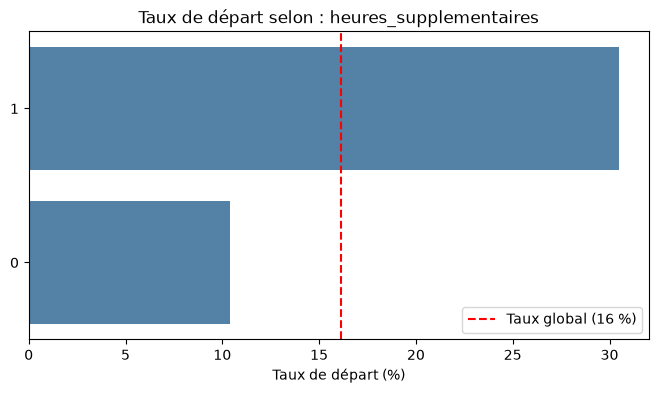

,Effectif,Départs,Taux de départ (%)
nombre_participation_pee,,,
0,631,154,24.4
3,85,15,17.6
1,596,56,9.4
2,158,12,7.6


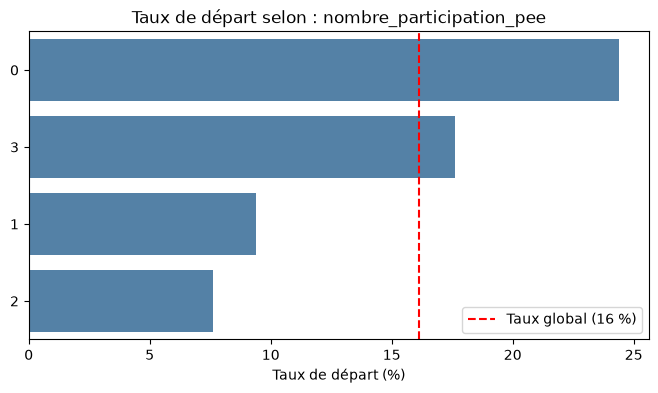

,Effectif,Départs,Taux de départ (%)
departement,,,
Commercial,446,92,20.6
Ressources Humaines,63,12,19.0
Consulting,961,133,13.8


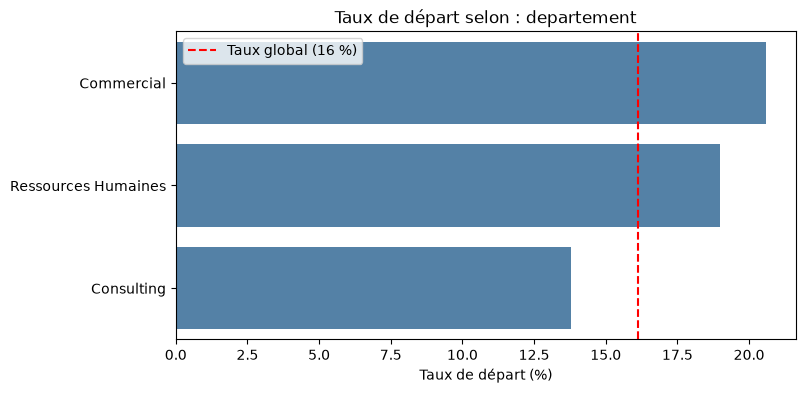

,Effectif,Départs,Taux de départ (%)
poste,,,
Représentant Commercial,83,33,39.8
Consultant,259,62,23.9
Ressources Humaines,52,12,23.1
Cadre Commercial,326,57,17.5
Assistant de Direction,292,47,16.1
Tech Lead,145,10,6.9
Manager,131,9,6.9
Senior Manager,102,5,4.9
Directeur Technique,80,2,2.5


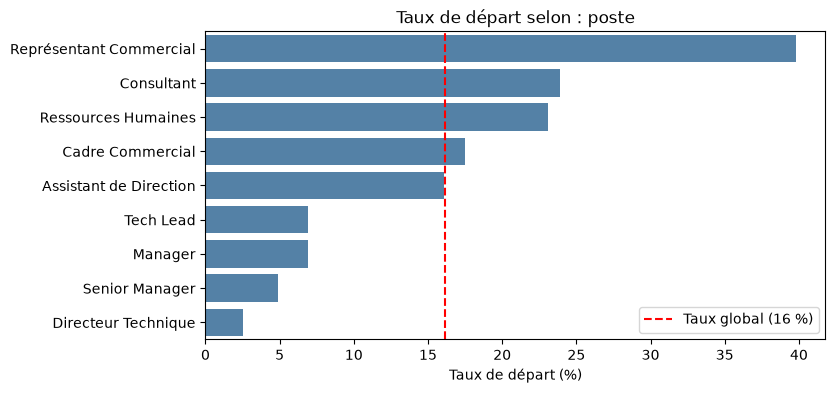

,Effectif,Départs,Taux de départ (%)
statut_marital,,,
Célibataire,470,120,25.5
Marié(e),673,84,12.5
Divorcé(e),327,33,10.1


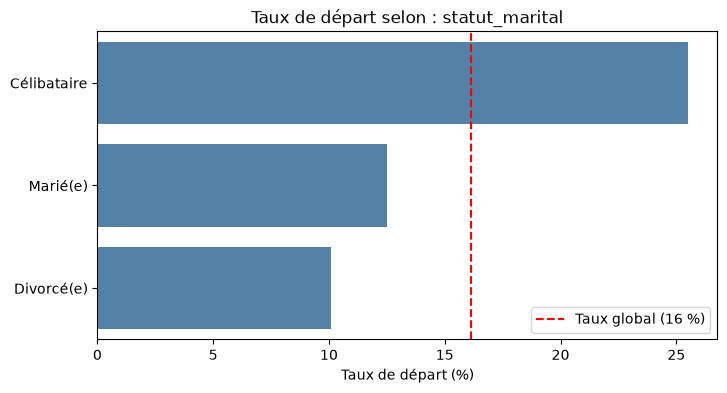

,Effectif,Départs,Taux de départ (%)
genre,,,
M,882,150,17.0
F,588,87,14.8


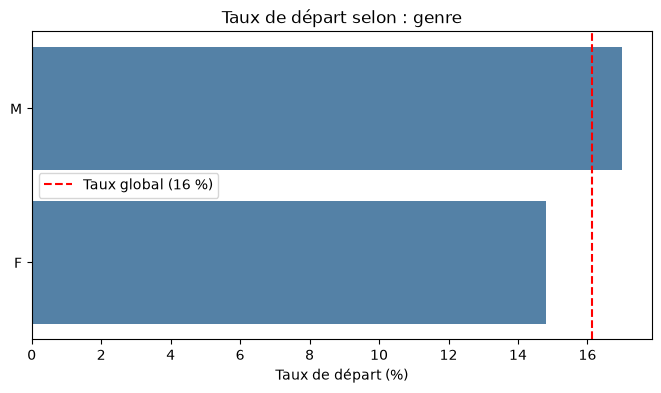

,Effectif,Départs,Taux de départ (%)
domaine_etude,,,
Ressources Humaines,27,7,25.9
Entrepreunariat,132,32,24.2
Marketing,159,35,22.0
Infra & Cloud,606,89,14.7
Transformation Digitale,464,63,13.6
Autre,82,11,13.4


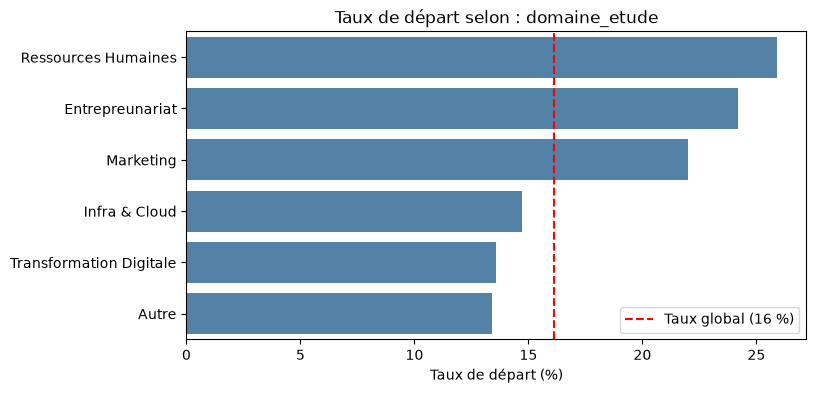

,Effectif,Départs,Taux de départ (%)
frequence_deplacement,,,
Frequent,277,69,24.9
Occasionnel,1043,156,15.0
Aucun,150,12,8.0


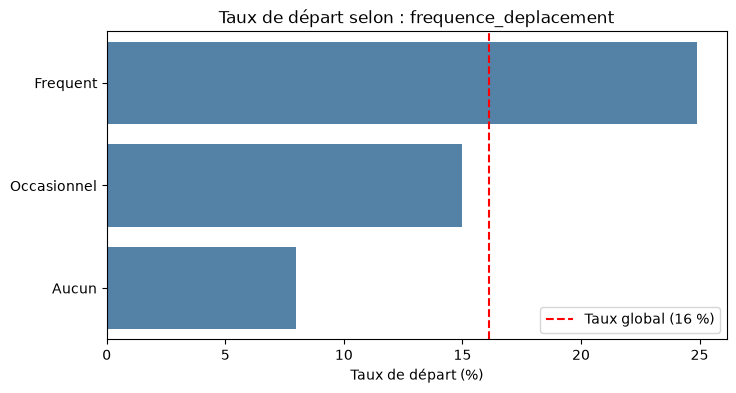

In [92]:
# ------------------------------------------------------------
# Fonction : taux de départ pour chaque valeur d'une colonne
# ------------------------------------------------------------
taux_global = df["a_quitte_l_entreprise"].mean() * 100   # environ 16 %

def taux_depart_par_groupe(df, colonne, trier_par_taux=True):
    """Affiche un tableau et un graphique du taux de départ pour chaque valeur de la colonne.
    trier_par_taux=True  : groupes triés du plus fort au plus faible taux (variables sans ordre : poste, domaine...)
    trier_par_taux=False : groupes dans leur ordre naturel (variables ordonnées : tranches, notes de 1 à 4...)
    """
    # 1) Pour chaque groupe : nombre d'employés, nombre de départs, taux de départ
    #    Rappel : la moyenne d'une colonne 0/1 = la proportion de 1
    tableau = df.groupby(colonne)["a_quitte_l_entreprise"].agg(["count", "sum", "mean"])
    tableau.columns = ["Effectif", "Départs", "Taux de départ (%)"]
    tableau["Taux de départ (%)"] = (tableau["Taux de départ (%)"] * 100).round(1)
    if trier_par_taux:
        tableau = tableau.sort_values("Taux de départ (%)", ascending=False)
    display(tableau)

    # 2) Graphique : une barre par groupe (dans l'ordre du tableau) + une ligne pour le taux global
    libelles = tableau.index.astype(str)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=tableau["Taux de départ (%)"].values, y=libelles,
                order=list(libelles), color="steelblue")
    plt.axvline(taux_global, color="red", linestyle="--", label=f"Taux global ({taux_global:.0f} %)")
    plt.title(f"Taux de départ selon : {colonne}")
    plt.xlabel("Taux de départ (%)")
    plt.ylabel("")
    plt.legend()
    plt.show()

# ------------------------------------------------------------
# Application à chaque variable concernée
# ------------------------------------------------------------
colonnes_a_analyser = [
    "heures_supplementaires", "nombre_participation_pee",
    "departement", "poste", "statut_marital", "genre",
    "domaine_etude", "frequence_deplacement",
]
for col in colonnes_a_analyser:
    taux_depart_par_groupe(df, col)

In [93]:
# Proportion de chaque fréquence de déplacement DANS chaque département
# normalize="index" = pourcentages par ligne (chaque ligne totalise 100 %)
display(pd.crosstab(df["departement"], df["frequence_deplacement"], normalize="index").round(2))

frequence_deplacement,Aucun,Frequent,Occasionnel
departement,,,
Commercial,0.11,0.19,0.71
Consulting,0.10,0.19,0.71
Ressources Humaines,0.10,0.17,0.73


La répartition des fréquences de déplacement est quasiment identique dans les 3 départements (environ 19 % de voyageurs fréquents partout) : l'effet des déplacements sur les départs **n'est donc pas un effet déguisé du département commercial**.

In [94]:
# Répartition des postes dans chaque département : explique l'effet de composition
display(pd.crosstab(df["poste"], df["departement"]))

departement,Commercial,Consulting,Ressources Humaines
poste,,,
Assistant de Direction,0,292,0
Cadre Commercial,326,0,0
Consultant,0,259,0
Directeur Technique,0,80,0
Manager,0,131,0
Représentant Commercial,83,0,0
Ressources Humaines,0,0,52
Senior Manager,37,54,11
Tech Lead,0,145,0


**Synthèse : taux de départ par groupe** (taux global : 16 %)

- **Heures supplémentaires** : 30,5 % de départs avec heures sup, contre 10,4 % sans → **risque environ 3 fois plus élevé**
- **Poste** : forte corrélation avec la séniorité : 40 % chez les représentants commerciaux, 24 % chez les consultants, contre moins de 7 % pour les postes d'encadrement (2,5 % chez les directeurs techniques)
- **Département** : Consulting affiche le taux le plus bas (13,8 %) alors que ses consultants partent beaucoup (23,9 %) → **effet de composition** : les nombreux postes d'encadrement du département diluent le taux. Le poste est plus informatif que le département.
- **Fréquence de déplacement** : 25 % de départs chez les voyageurs fréquents, 15 % en occasionnel, 8 % sans déplacement. Effet indépendant du département (même répartition des déplacements partout) → **levier actionnable**
- **PEE** : 24 % de départs chez ceux qui n'y ont jamais participé, contre environ 9 % dès une participation (interprété comme Plan d'Épargne Entreprise, sigle non documenté)
- **Statut marital** : 25 % de départs chez les célibataires, contre 12 % chez les mariés et 10 % chez les divorcés
- **Domaine d'étude** : taux plus élevés en Entrepreneuriat (24 %) et Marketing (22 %) ; le taux de 26 % en RH repose sur seulement 27 personnes → peu fiable
- **Genre** : pas de différence notable

**Points de vigilance**
- Statut marital et genre sont des variables **sensibles et non actionnables** : utiles pour comprendre, pas pour agir
- Redondance **poste / département** (le poste détermine presque toujours le département) → à traiter à l'étape 2
- Ces taux montrent des **liens**, pas des causes

### 3.4 Variables numériques continues : âge, salaire, ancienneté, distance

#### 3.4.1 Comparaison des distributions (restés / partis)

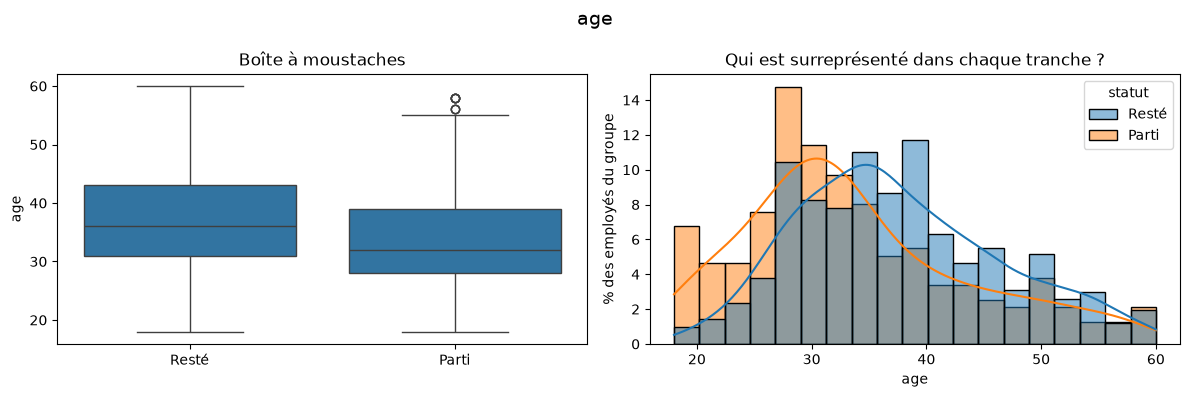

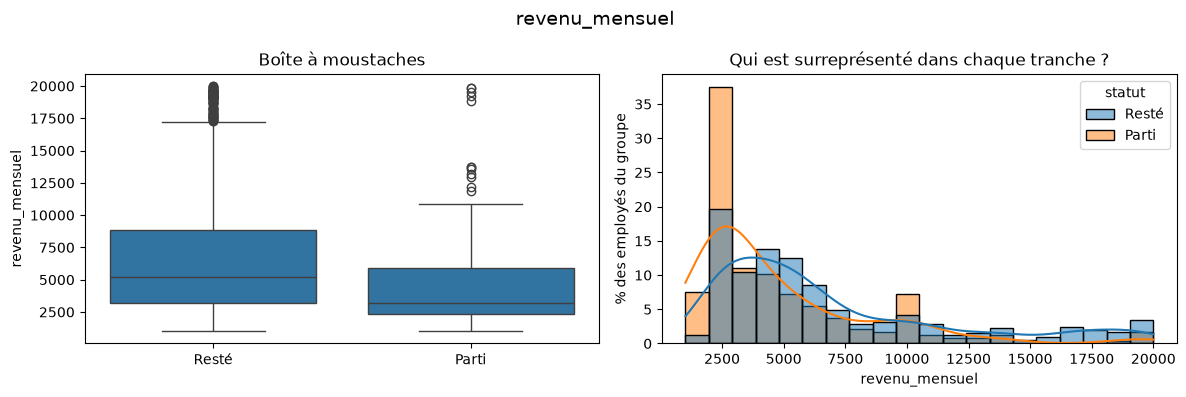

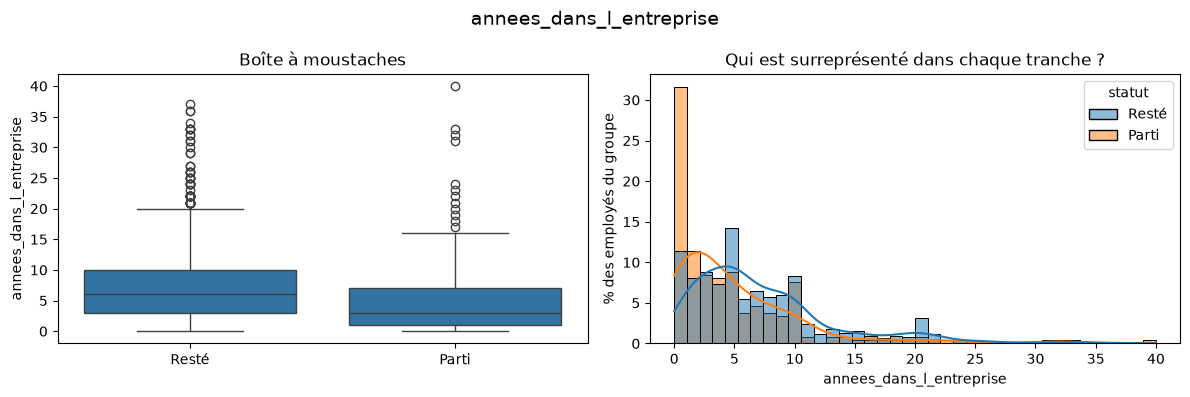

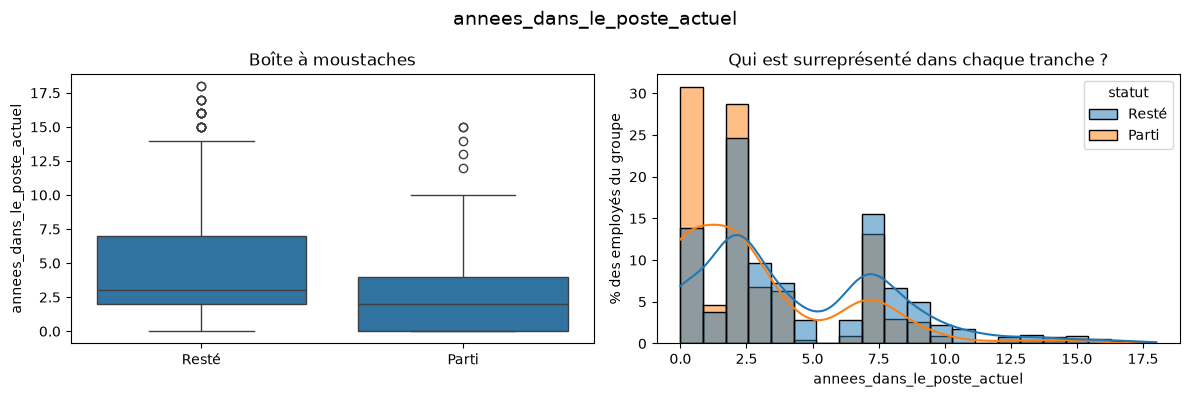

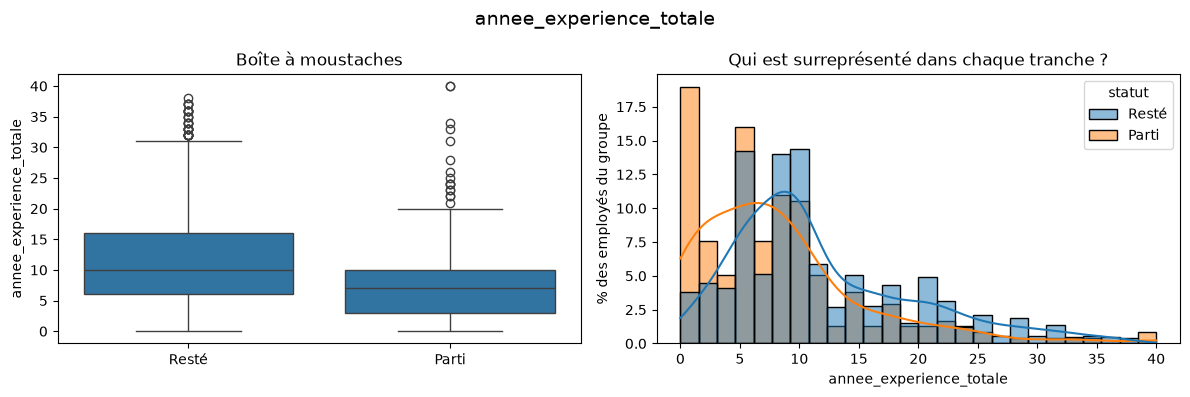

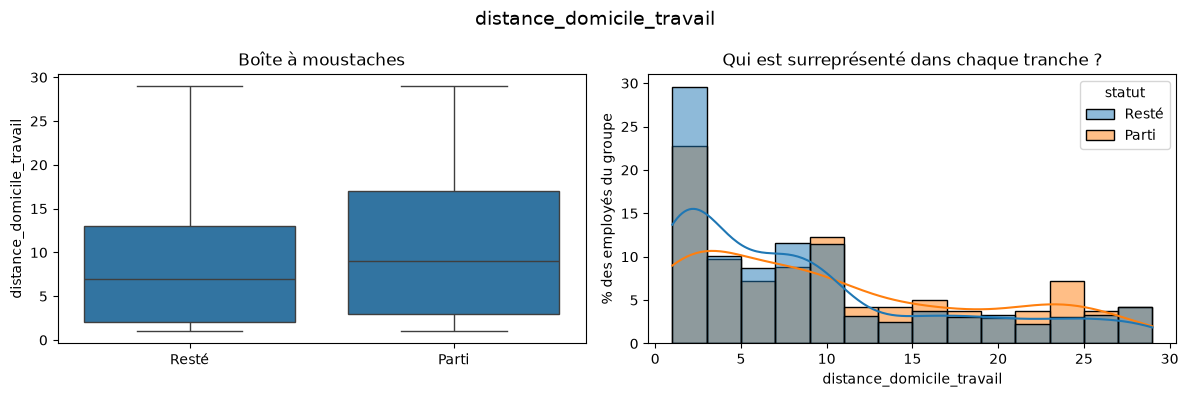

In [95]:
# ------------------------------------------------------------
# Fonction : compare la distribution d'une variable entre restés et partis
# ------------------------------------------------------------
def comparer_distribution(df, colonne):
    """Affiche un boxplot et un histogramme superposé de la colonne, selon le statut de départ."""
    # Colonne temporaire avec des libellés lisibles pour les graphiques (0/1 -> Resté/Parti)
    df_graph = df.assign(statut=df["a_quitte_l_entreprise"].map({0: "Resté", 1: "Parti"}))

    # 2 graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Gauche : boxplot
    sns.boxplot(data=df_graph, x="statut", y=colonne, order=["Resté", "Parti"], ax=axes[0])
    axes[0].set_title("Boîte à moustaches")
    axes[0].set_xlabel("")

    # Droite : histogrammes superposés
    # stat="percent" + common_norm=False : chaque groupe est ramené à 100 %,
    # la hauteur d'une barre = % des employés DU GROUPE qui tombent dans cette tranche.
    # Indispensable ici : sinon les 1 233 restés écraseraient les 237 partis
    # et on ne verrait pas la forme de leur distribution.
    sns.histplot(data=df_graph, x=colonne, hue="statut", hue_order=["Resté", "Parti"],
                 stat="percent", common_norm=False, kde=True, ax=axes[1])
    axes[1].set_title("Qui est surreprésenté dans chaque tranche ?")
    axes[1].set_ylabel("% des employés du groupe")

    fig.suptitle(colonne, fontsize=14)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Application aux variables continues
# ------------------------------------------------------------
colonnes_continues = [
    "age", "revenu_mensuel", "annees_dans_l_entreprise", "annees_dans_le_poste_actuel",
    "annee_experience_totale", "distance_domicile_travail",
]
for col in colonnes_continues:
    comparer_distribution(df, col)

**Observations**
- **Âge** : les partants sont surreprésentés avant 32 ans environ, avec un pic chez les plus jeunes ; les restants dominent à partir de 35 ans.
- **Salaire** : les partants sont très concentrés dans les bas salaires (autour de 2 500 €). On observe aussi une légère surreprésentation autour de 10 000 €, qui suggère une relation **non monotone**.
- **Ancienneté** : près d'un tiers des partants ont moins de 2 ans d'ancienneté dans l'entreprise.
- **Distance du lieu de travail** : en dessous de 10Km de trajet, les restants sont dominants
- **Expérience Totale** : en dessous de 8 ans d'expérience totale, les partants sont dominants

Ensuite, pour mesurer le **risque** de départ (et non seulement la répartition), on découpe le salaire et l'ancienneté en tranches.

#### 3.4.2 Taux de départ par tranche (salaire, ancienneté)

,Effectif,Départs,Taux de départ (%)
tranche_salaire,,,
Moins de 2 500 €,226,77,34.1
2 500 à 5 000 €,523,86,16.4
5 000 à 7 500 €,310,30,9.7
7 500 à 10 000 €,130,19,14.6
10 000 à 12 500 €,91,15,16.5
Plus de 12 500 €,190,10,5.3


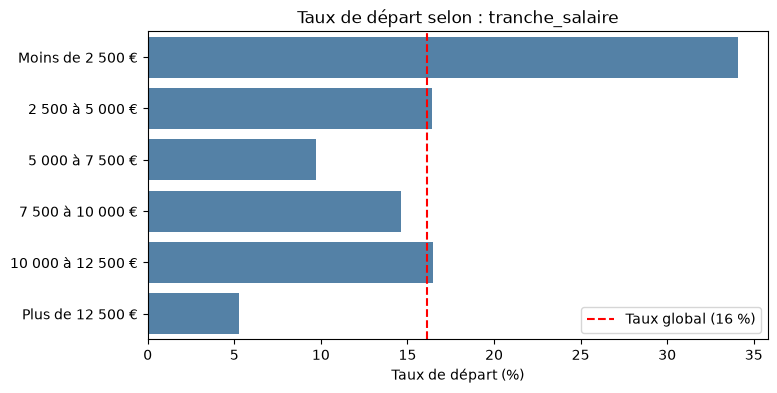

In [96]:
# ------------------------------------------------------------
# Taux de départ par tranche de salaire
# ------------------------------------------------------------
# bins   : bornes des tranches
# labels : noms lisibles des tranches (un de moins que le nombre de bornes)
df_tranches = df.assign(tranche_salaire=pd.cut(
    df["revenu_mensuel"],
    bins=[0, 2500, 5000, 7500, 10000, 12500, 20000],
    labels=["Moins de 2 500 €", "2 500 à 5 000 €", "5 000 à 7 500 €",
            "7 500 à 10 000 €", "10 000 à 12 500 €", "Plus de 12 500 €"],
))
taux_depart_par_groupe(df_tranches, "tranche_salaire", trier_par_taux=False)

,Effectif,Départs,Taux de départ (%)
tranche_anciennete,,,
Moins d'1 an,44,16,36.4
1 an,171,59,34.5
2 ans,127,27,21.3
3 à 5 ans,434,60,13.8
6 à 10 ans,448,55,12.3
Plus de 10 ans,246,20,8.1


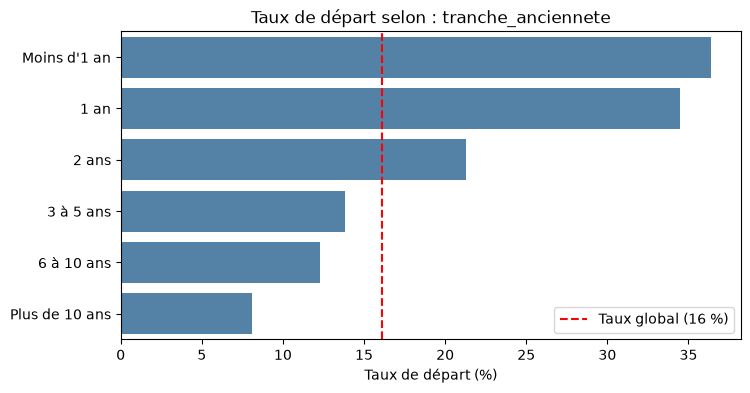

In [97]:
# ------------------------------------------------------------
# Taux de départ par tranche d'ancienneté dans l'entreprise
# ------------------------------------------------------------
# bins   : bornes des tranches (la borne -1 permet d'inclure les employés à 0 an)
# labels : noms lisibles des tranches (un de moins que le nombre de bornes)
df_tranches = df.assign(tranche_anciennete=pd.cut(
    df["annees_dans_l_entreprise"],
    bins=[-1, 0, 1, 2, 5, 10, 50],
    labels=["Moins d'1 an", "1 an", "2 ans", "3 à 5 ans", "6 à 10 ans", "Plus de 10 ans"],
))
taux_depart_par_groupe(df_tranches, "tranche_anciennete", trier_par_taux=False)

**Conclusions**
- **Salaire** : le risque de départ est maximal sous 2 500 € (**34 %**, soit deux fois le taux global), puis diminue… avant de remonter à 15-16 % entre 7 500 et 12 500 €, et de chuter à 5 % au-delà. Ce rebond reste un signal modéré (une quinzaine de départs par tranche).
- **Ancienneté** : **plus d'un employé sur trois part dans ses deux premières années** (36 % la première année, 35 % la deuxième), puis le risque baisse régulièrement jusqu'à 8 % au-delà de 10 ans.

**Hypothèses à confirmer avec les RH** (non vérifiables avec ces données) : intégration ou accompagnement insuffisant des nouveaux arrivants, rémunération d'entrée peu compétitive par rapport au marché.

### 3.5 Satisfaction : taux de départ par niveau

La satisfaction est au cœur du sondage annuel et constitue un levier d'action direct pour les RH.
Le tableau de la partie 3.2 montrait des moyennes légèrement plus faibles chez les partants (environ -11 % sur la nature du travail et l'environnement), mais une moyenne sur une échelle de 1 à 4 est difficile à interpréter.

Ces notes ne prennent que 4 valeurs ordonnées : on les traite donc comme des **niveaux**, en calculant le taux de départ pour chacun d'eux.
**Question posée : le risque de départ diminue-t-il quand la satisfaction augmente ?**

,Effectif,Départs,Taux de départ (%)
satisfaction_employee_environnement,,,
1,284,72,25.4
2,287,43,15.0
3,453,62,13.7
4,446,60,13.5


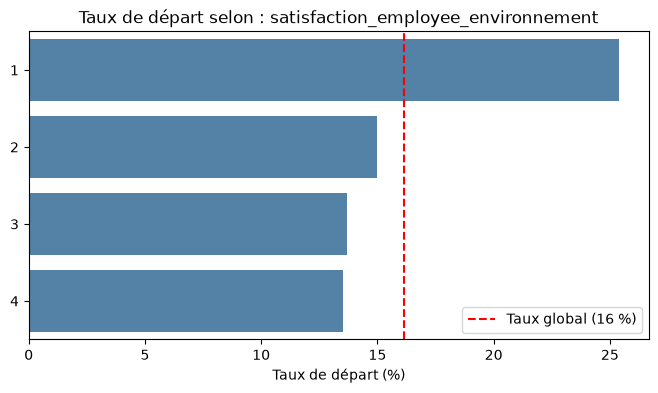

,Effectif,Départs,Taux de départ (%)
satisfaction_employee_nature_travail,,,
1,289,66,22.8
2,280,46,16.4
3,442,73,16.5
4,459,52,11.3


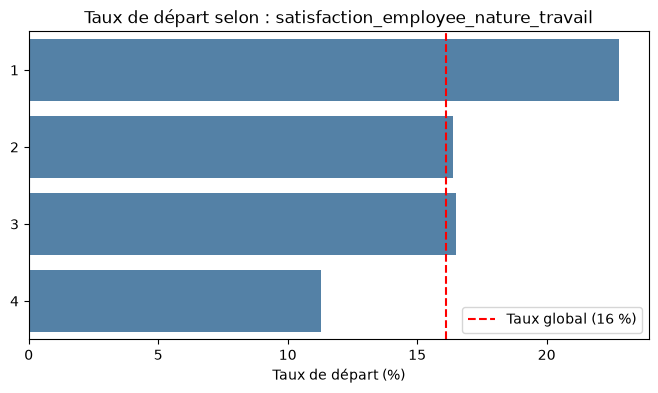

,Effectif,Départs,Taux de départ (%)
satisfaction_employee_equipe,,,
1,276,57,20.7
2,303,45,14.9
3,459,71,15.5
4,432,64,14.8


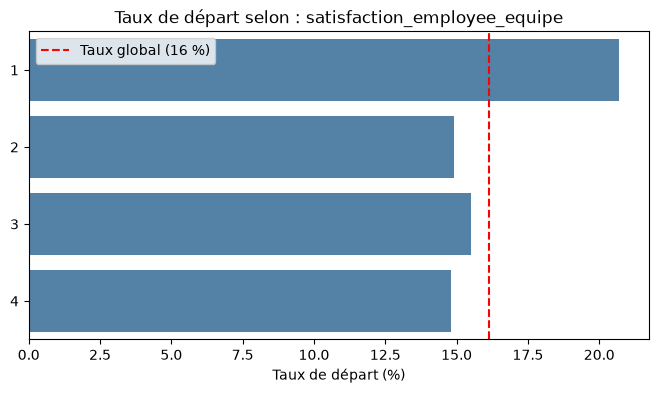

,Effectif,Départs,Taux de départ (%)
satisfaction_employee_equilibre_pro_perso,,,
1,80,25,31.2
2,344,58,16.9
3,893,127,14.2
4,153,27,17.6


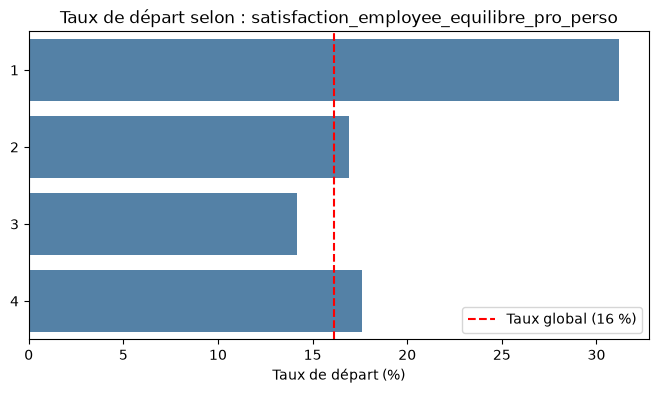

In [98]:
# ------------------------------------------------------------
# Satisfaction (notes de 1 à 4) : taux de départ par niveau
# ------------------------------------------------------------
colonnes_satisfaction = [ 
    "satisfaction_employee_environnement", "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe", "satisfaction_employee_equilibre_pro_perso",
]
for col in colonnes_satisfaction:
    taux_depart_par_groupe(df, col, trier_par_taux=False) # On reprends la fonction de l'étape 3.3

**Conclusions**
- **Effet de seuil** : c'est surtout la note **1** (très insatisfait) qui est associée à un risque de départ plus élevé
- Entre les notes 2, 3 et 4, les écarts sont faibles, sauf pour la **nature du travail**, où la note 4 descend à 11 %.
- Ces effets restent **moins marqués** que ceux des heures supplémentaires ou de l'ancienneté.

Piste actionnable : une note de 1 dans le sondage annuel pourrait servir de **signal d'alerte** pour les RH.

### 3.6 Synthèse de l'analyse exploratoire

Sur 1 470 employés, **237 sont partis (16 %)**. Les principaux profils à risque :

1. **Heures supplémentaires** : 30,5 % de départs, contre 10,4 % sans → risque environ **3 fois plus élevé**. Levier actionnable.
2. **Premières années dans l'entreprise** : **plus d'un employé sur trois** part dans ses deux premières années, contre 8 % au-delà de 10 ans. Pointe vers l'intégration des nouveaux arrivants.
3. **Postes juniors et bas salaires** : 40 % de départs chez les représentants commerciaux, 34 % sous 2 500 € de salaire, contre moins de 7 % dans les postes d'encadrement.
4. **Déplacements fréquents** : 25 % de départs, contre 8 % sans déplacement, indépendamment du département. Levier actionnable.
5. **Très faible satisfaction** : une note de 1 est associée à un risque de départ plus élevé (21 à 31 % selon la dimension), un signal d'alerte exploitable dans le sondage annuel.

**À retenir pour la modélisation (étape 2)**
- Plusieurs familles de variables sont **redondantes** (ancienneté / âge / expérience ; salaire / niveau hiérarchique ; poste / département), à vérifier avec une matrice de corrélation.
- Certaines relations sont **non linéaires** (rebond du taux de départ entre 7 500 et 12 500 €, effet de seuil de la satisfaction), argument en faveur d'un modèle non linéaire.
- Ces constats décrivent des **liens**, pas des causes : le modèle et l'analyse SHAP permettront de mesurer le poids de chaque facteur **à caractéristiques égales**.

## 4. Préparation des données pour la modélisation
### 4.1 Corrélations linéaires entre features (Pearson)

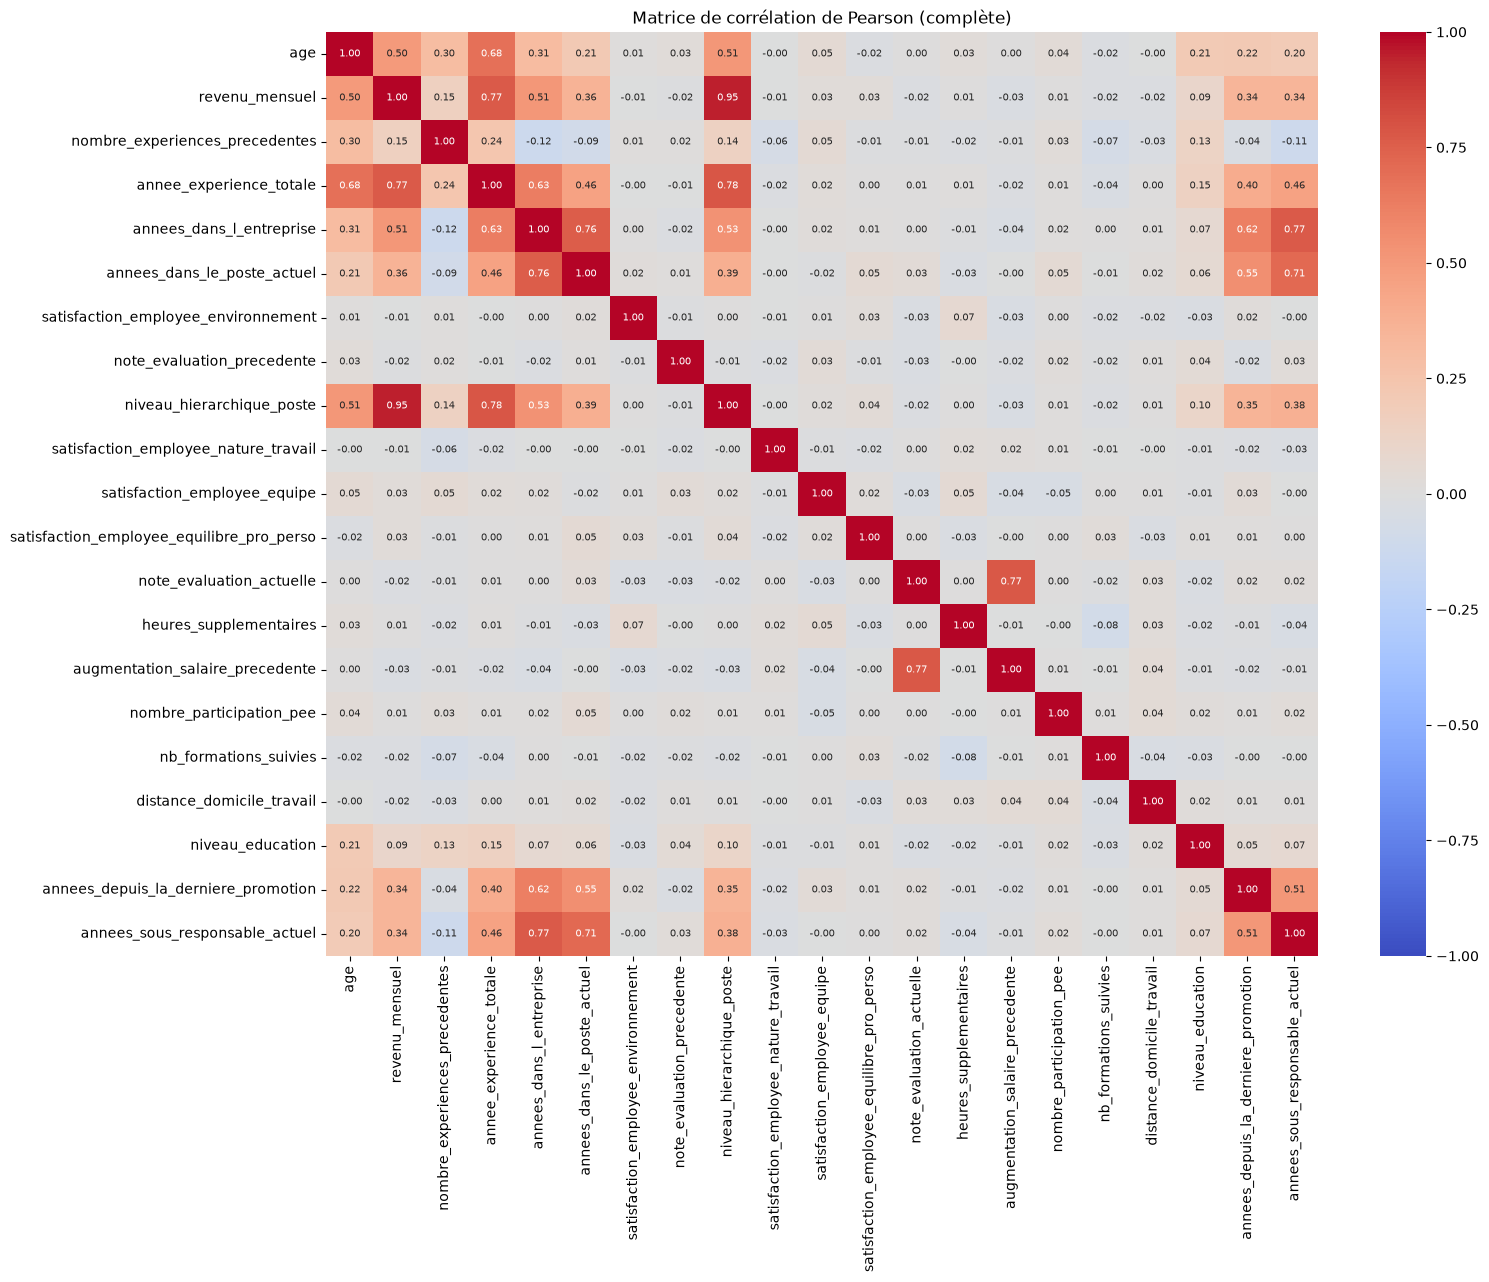

In [99]:
# On exclut l'identifiant (aucun sens) et la cible (on étudie ici les liens ENTRE features)
colonnes_num = df.select_dtypes(include="number").columns.drop(["id_employee", "a_quitte_l_entreprise"])
matrice_pearson = df[colonnes_num].corr(method="pearson")

# Affichage
plt.figure(figsize=(16, 12))
sns.heatmap(matrice_pearson, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Matrice de corrélation de Pearson (complète)")
plt.show()

**Observations**
- La **diagonale** vaut toujours 1 : chaque variable est parfaitement corrélée avec elle-même. Elle n'apporte aucune information.
- La matrice est **symétrique** : la corrélation entre A et B est la même que entre B et A. Chaque valeur apparaît donc deux fois.

Amélioration, on n'affiche que la moitié basse, pour une lecture deux fois plus légère.

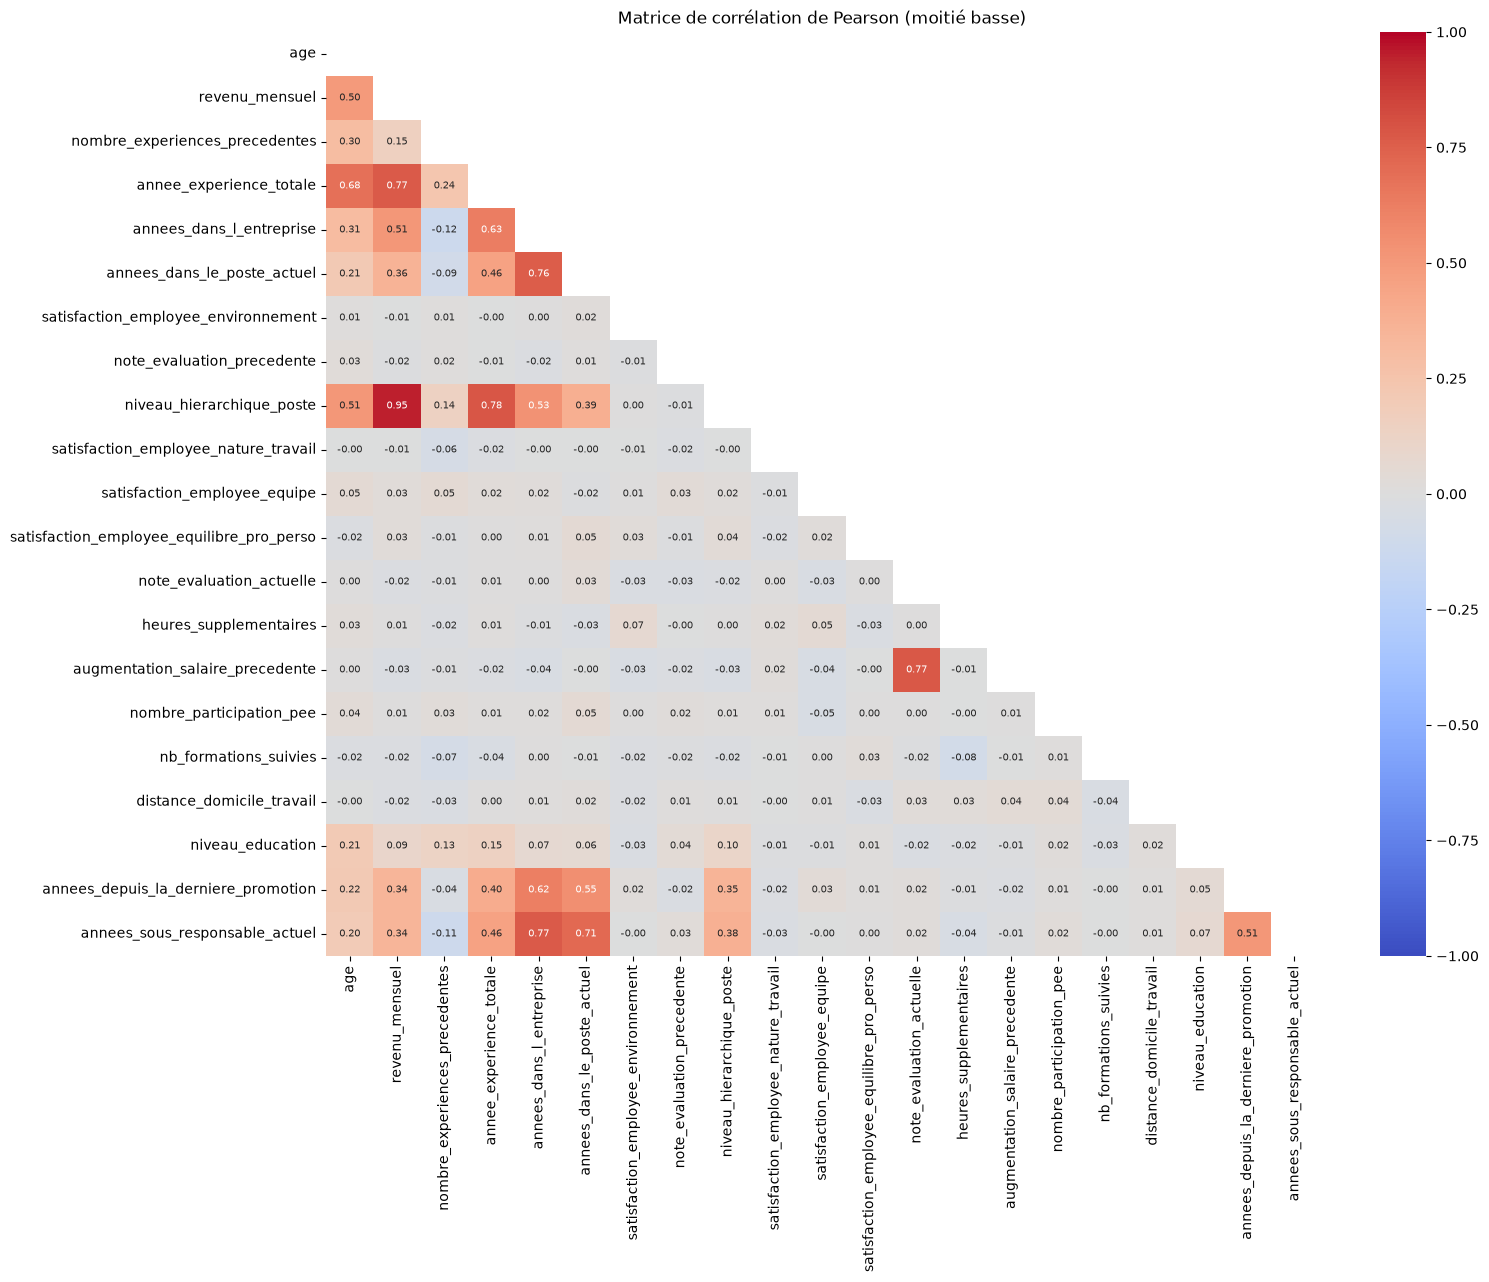

In [100]:
# ------------------------------------------------------------
# Matrice de Pearson : moitié basse uniquement
# ------------------------------------------------------------
# np.triu = "triangle supérieur" : on crée un masque qui vaut True sur la diagonale
# et au-dessus ; seaborn cache toutes les cases où le masque vaut True
masque = np.triu(np.ones_like(matrice_pearson, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(matrice_pearson, mask=masque, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Matrice de corrélation de Pearson (moitié basse)")
plt.show()

Plus lisible, mais il y a toujours beaucoup de zones correlées, prenons les plus correlées (+ de 0.70)

In [101]:
# ------------------------------------------------------------
# Fonction : liste les paires de variables fortement corrélées
# ------------------------------------------------------------
def paires_fortement_correlees(matrice, seuil=0.7):
    """Renvoie les paires dont la corrélation (en valeur absolue) dépasse le seuil."""
    paires = []
    colonnes = matrice.columns
    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):   # j > i : chaque paire n'est comptée qu'une fois
            valeur = matrice.iloc[i, j]
            if abs(valeur) >= seuil:            # abs() : une forte corrélation négative compte aussi
                paires.append((colonnes[i], colonnes[j], round(valeur, 2)))
    return pd.DataFrame(paires, columns=["Variable 1", "Variable 2", "Corrélation"]).sort_values("Corrélation", ascending=False)

display(paires_fortement_correlees(matrice_pearson, seuil=0.7))

,Variable 1,Variable 2,Corrélation
1,revenu_mensuel,niveau_hierarchique_poste,0.95
2,annee_experience_totale,niveau_hierarchique_poste,0.78
0,revenu_mensuel,annee_experience_totale,0.77
4,annees_dans_l_entreprise,annees_sous_responsable_actuel,0.77
6,note_evaluation_actuelle,augmentation_salaire_precedente,0.77
3,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.76
5,annees_dans_le_poste_actuel,annees_sous_responsable_actuel,0.71


**Observations** : 7 paires dépassent le seuil de 0,7, regroupées en 3 familles :
- **Rémunération / séniorité** : `revenu_mensuel` et `niveau_hierarchique_poste` sont quasi redondants (0,95) ; `annee_experience_totale` leur est fortement liée (0,77-0,78), le revenu me paraît plus parlant pour la suite
- **Ancienneté interne** : années dans l'entreprise, dans le poste et sous le responsable actuel évoluent ensemble (0,71 à 0,77), année dans l'entreprise me paraît plus logique si j'en conserve une seule
- **Évaluation** : `note_evaluation_actuelle` et `augmentation_salaire_precedente` (0,77), l'augmentation dépendant logiquement de la note. Aucune des deux ne distingue partants et restants.

Une variable par famille devra probablement être retirée. Décision après l'analyse des relations non linéaires

### 4.2 Relations non linéaires (pairplot et Spearman)

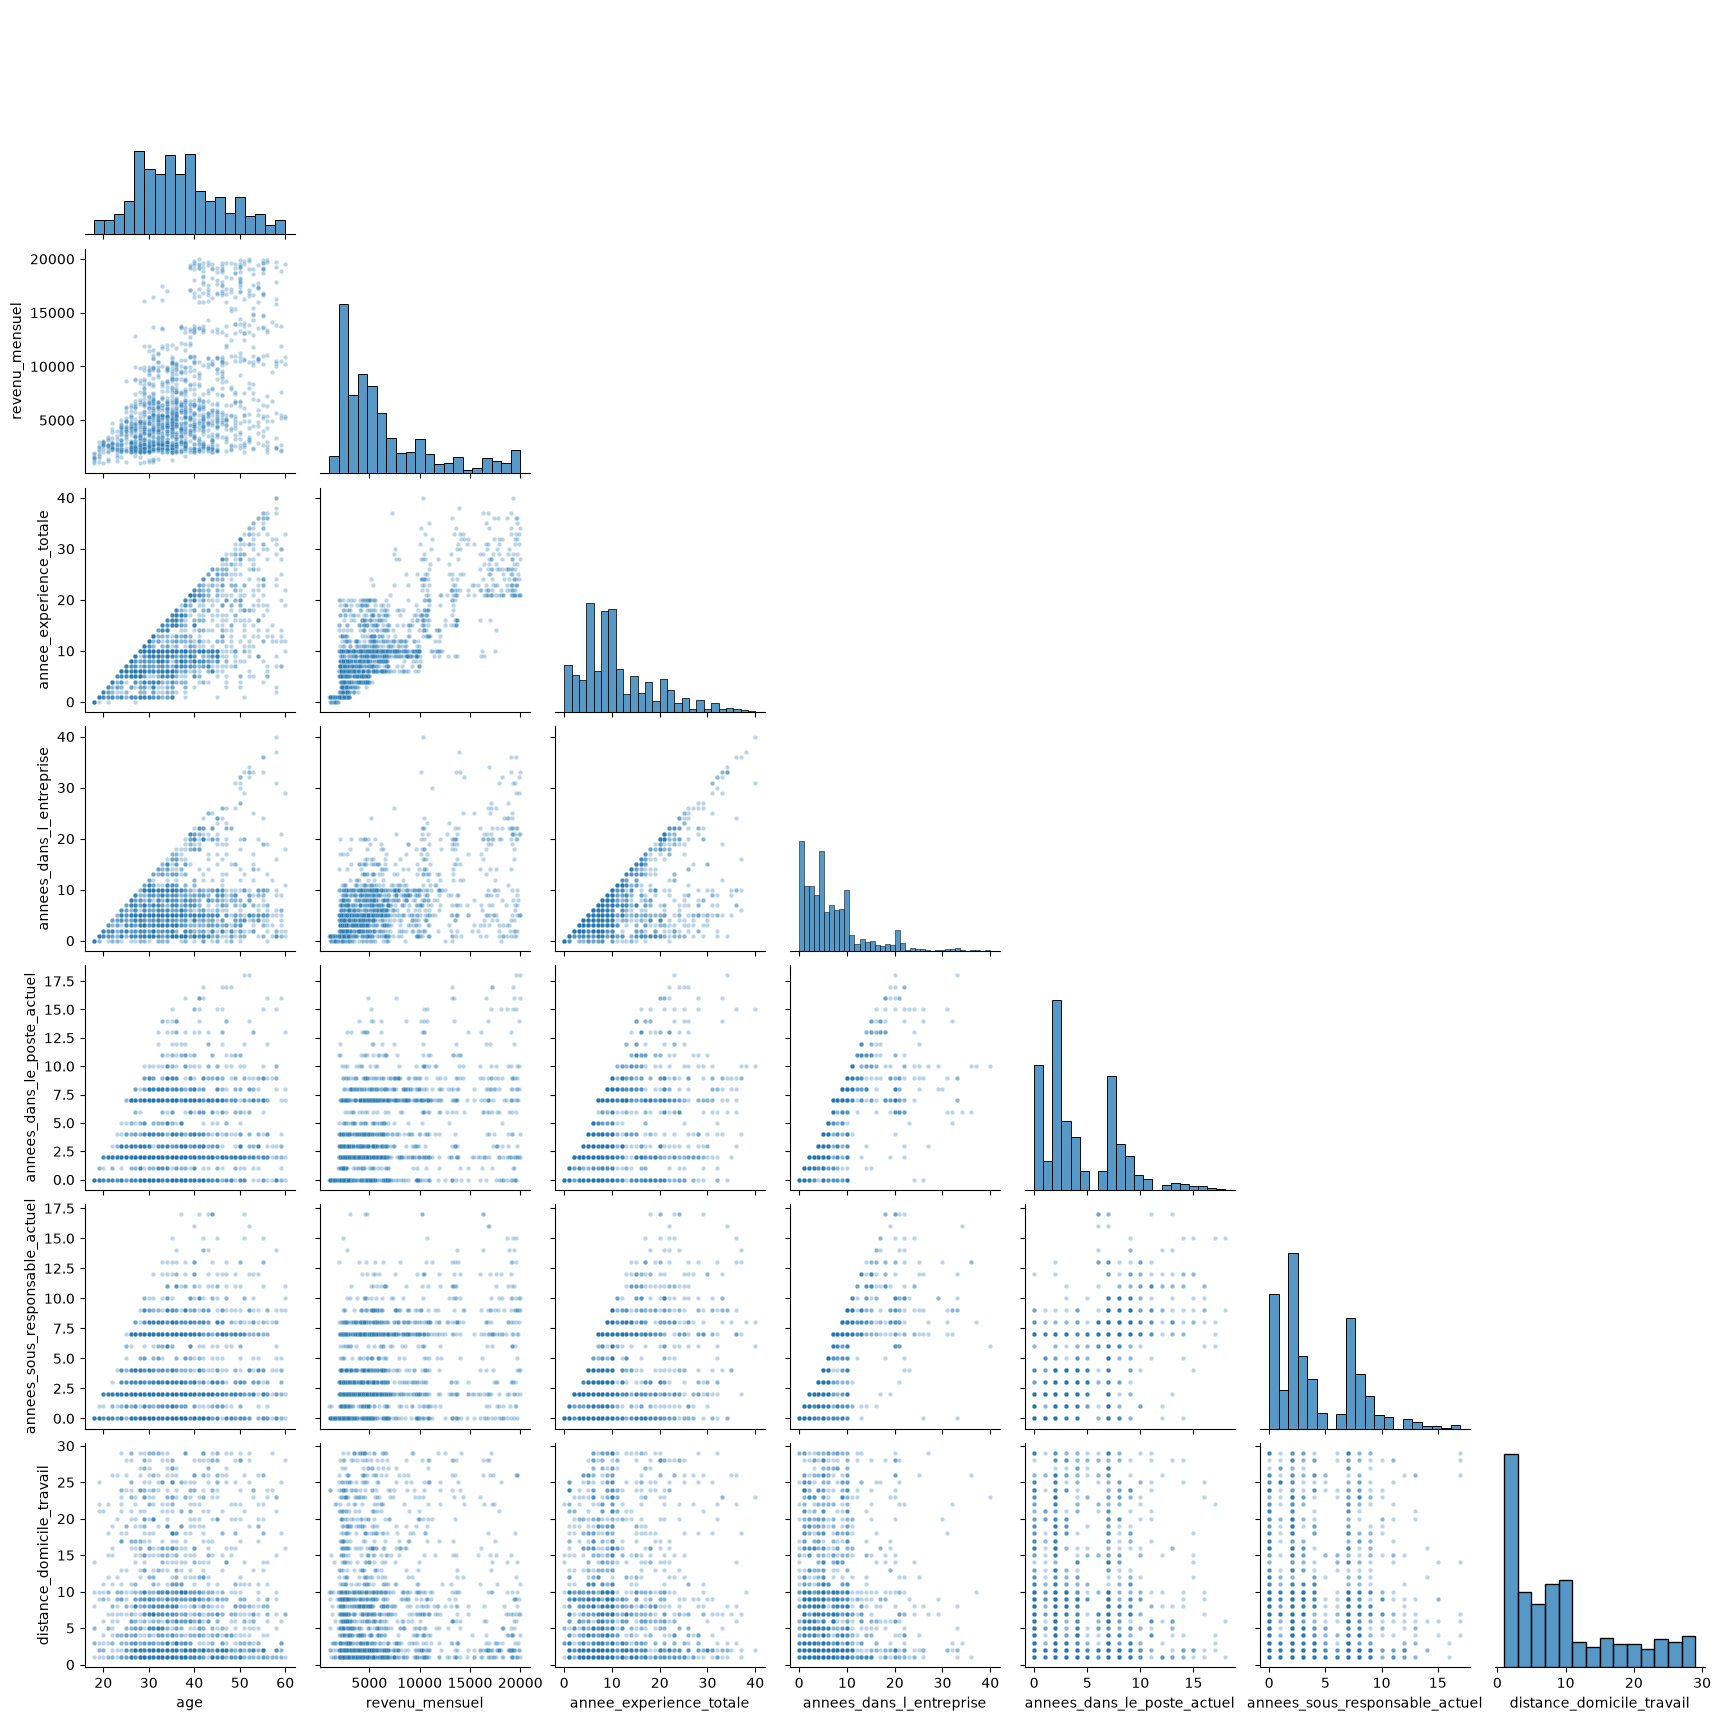

In [102]:
# ------------------------------------------------------------
# Pairplot : nuage de points pour chaque paire de variables continues
# ------------------------------------------------------------
# On se limite aux variables continues principales
colonnes_pairplot = [
    "age", "revenu_mensuel", "annee_experience_totale", "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel", "annees_sous_responsable_actuel", "distance_domicile_travail",
]
# corner=True : moitié basse uniquement (même logique que la heatmap)
# alpha=0.3   : points semi-transparents, pour voir où ils s'accumulent
sns.pairplot(df[colonnes_pairplot], corner=True, plot_kws={"alpha": 0.3, "s": 10})
plt.show()

**Lecture du pairplot**
- **Formes triangulaires** (âge, expérience, ancienneté entreprise / poste / responsable) : contraintes logiques (on ne peut pas avoir plus d'ancienneté que d'expérience, etc.).  
Aucun point ne dépasse ces limites **données cohérentes**.
- **Revenu × expérience** : relation croissante mais éparpillée, pas strictement linéaire.
- **Distance domicile-travail** : aucune relation avec les autres variables, information indépendante, à conserver.
- Revenu et distance ont des distributions **asymétriques** (beaucoup de petites valeurs).

In [103]:
# ------------------------------------------------------------
# Matrice de Spearman et comparaison avec Pearson
# ------------------------------------------------------------
matrice_spearman = df[colonnes_num].corr(method="spearman")

# 1) Paires fortement corrélées selon Spearman (même fonction et même seuil qu'au dessus)
display(paires_fortement_correlees(matrice_spearman, seuil=0.7))

# 2) Écart Spearman - Pearson : les 10 plus grands écarts, triés
#    Un écart important signalerait une relation non linéaire
ecart = (matrice_spearman - matrice_pearson).abs()
display(paires_fortement_correlees(ecart, seuil=0)
        .rename(columns={"Corrélation": "Écart Spearman - Pearson"})
        .head(10))

,Variable 1,Variable 2,Corrélation
1,revenu_mensuel,niveau_hierarchique_poste,0.92
3,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.85
4,annees_dans_l_entreprise,annees_sous_responsable_actuel,0.84
2,annee_experience_totale,niveau_hierarchique_poste,0.73
5,annees_dans_le_poste_actuel,annees_sous_responsable_actuel,0.72
0,revenu_mensuel,annee_experience_totale,0.71


,Variable 1,Variable 2,Écart Spearman - Pearson
175,note_evaluation_actuelle,augmentation_salaire_precedente,0.15
74,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.10
88,annees_dans_l_entreprise,annees_depuis_la_derniere_promotion,0.10
142,niveau_hierarchique_poste,annees_depuis_la_derniere_promotion,0.08
37,revenu_mensuel,annees_depuis_la_derniere_promotion,0.08
39,nombre_experiences_precedentes,annee_experience_totale,0.08
89,annees_dans_l_entreprise,annees_sous_responsable_actuel,0.07
72,annee_experience_totale,annees_depuis_la_derniere_promotion,0.07
77,annees_dans_l_entreprise,niveau_hierarchique_poste,0.06
21,revenu_mensuel,annee_experience_totale,0.06


- Les écarts Spearman - Pearson restent faibles (au maximum 0,145) **pas de relation non linéaire forte** non détectée par Pearson.  
Le plus grand écart concerne la paire note actuelle / augmentation, expliquée ci-dessous.

In [104]:
# La note actuelle est-elle entièrement déterminée par l'augmentation ?
display(df.groupby("note_evaluation_actuelle")["augmentation_salaire_precedente"].agg(["min", "max"]))

,min,max
note_evaluation_actuelle,,
3,11,19
4,20,25


**Observations Spearman**
- Les écarts Spearman - Pearson restent faibles (au maximum **0,15**) **pas de relation non linéaire forte** que Pearson n'aurait pas détectée.
- L'ancienneté interne est encore plus redondante qu'avec Pearson (0,84-0,85 contre 0,76-0,77) : relation monotone mais non linéaire, cohérente avec les formes triangulaires du pairplot.
- La paire note actuelle / augmentation présente le plus grand écart : elle passe de 0,77 (Pearson) à 0,63 (Spearman), sous le seuil de 0,7. Ce n'est pas une absence de lien : la note n'a que 2 valeurs  
La vérification directe montre au contraire une **redondance totale** : note 3 = augmentation de 11 à 19 %, note 4 = augmentation de 20 à 25 %.

### 4.3 Sélection des features redondantes

| Variable retirée | Conservée à sa place | Justification |
|---|---|---|
| `niveau_hierarchique_poste` | `revenu_mensuel` | Quasi-doublon (0,92-0,95) ; le revenu est plus précis et constitue un levier RH |
| `annees_sous_responsable_actuel` | `annees_dans_l_entreprise` | Variable la plus redondante de sa famille ; l'ancienneté entreprise est plus logique |
| `note_evaluation_actuelle` | `augmentation_salaire_precedente` | Entièrement déterminée par l'augmentation : aucune perte d'information |
| `departement` | `poste` | Variable texte, donc invisible pour Pearson / Spearman : le tableau croisé de la partie 3.3 montre que le poste détermine le département (sauf pour les Senior Managers). Le poste est plus informatif (effet de composition) |

Conservées malgré une corrélation de 0,71 à 0,85 : `annee_experience_totale` (inclut l'expérience hors TechNova) et `annees_dans_le_poste_actuel` (distingue mobilité interne et ancienneté).

In [105]:
# Suppression des features redondantes (décision 4.3)
# Liste  réutilisée dans la fonction finale de préparation des données.
COLONNES_REDONDANTES = [
    "niveau_hierarchique_poste",        # doublon de revenu_mensuel
    "annees_sous_responsable_actuel",   # doublon de l'ancienneté entreprise / poste
    "note_evaluation_actuelle",         # entièrement déterminée par l'augmentation
    "departement",                      # quasiment déterminé par le poste (cf. 3.3)
]

# Copie de travail : df reste intact pour l'analyse exploratoire
df_modele = df.drop(columns=COLONNES_REDONDANTES)
print("Avant :", df.shape, "→ Après :", df_modele.shape)   # attendu : 29 → 25 colonnes

# ------------------------------------------------------------
# Vérification : quelles paires dépassent encore 0,7 ?
# ------------------------------------------------------------
colonnes_num_modele = df_modele.select_dtypes(include="number").columns.drop(["id_employee", "a_quitte_l_entreprise"])
display(paires_fortement_correlees(df_modele[colonnes_num_modele].corr(method="spearman"), seuil=0.7))

Avant : (1470, 29) → Après : (1470, 25)


,Variable 1,Variable 2,Corrélation
1,annees_dans_l_entreprise,annees_dans_le_poste_actuel,0.85
0,revenu_mensuel,annee_experience_totale,0.71


Il ne reste bien que 2 paires au-dessus de 0,7, correspondant aux variables conservées (expérience totale, années dans le poste)

### 4.4 Feature engineering
Création de variables candidates, puis vérification de leur lien avec le départ avant de les retenir.

#### 4.4.1 Test des features candidates

In [106]:
# ------------------------------------------------------------
# Calcul des 3 features candidates (sur une copie temporaire)
# ------------------------------------------------------------
COLONNES_SATISFACTION = [
    "satisfaction_employee_environnement", "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe", "satisfaction_employee_equilibre_pro_perso",
]

# .assign() crée de nouvelles colonnes et renvoie une COPIE : df_modele n'est pas modifié
df_candidates = df_modele.assign(
    # Taux de mobilité : entreprises précédentes par année d'expérience ("+ 1" évite la division par zéro)
    taux_mobilite=df_modele["nombre_experiences_precedentes"] / (df_modele["annee_experience_totale"] + 1),
    # Nombre de dimensions de satisfaction notées 1 ; .sum(axis=1) compte ligne par ligne
    nb_satisfactions_a_1=(df_modele[COLONNES_SATISFACTION] == 1).sum(axis=1),
    # Âge à l'embauche
    age_embauche=df_modele["age"] - df_modele["annees_dans_l_entreprise"],
)

display(df_candidates[["taux_mobilite", "nb_satisfactions_a_1", "age_embauche"]].describe())

,taux_mobilite,nb_satisfactions_a_1,age_embauche
count,1470.000000,1470.000000,1470.000000
mean,0.278598,0.631973,29.915646
std,0.294419,0.731429,9.281306
min,0.000000,0.000000,18.000000
25%,0.090909,0.000000,22.000000
50%,0.176471,1.000000,28.000000
75%,0.390700,1.000000,36.000000
max,2.250000,4.000000,59.000000


Valeur étonnante dans `taux_mobilite` le max est au dessus de 1 indiquant plus d'une entreprise par année d'expérience.  
Je fais une liste pour détecter une erreur

In [107]:
# Cas où le nombre d'entreprises précédentes dépasse les années d'expérience
incoherents = df_candidates["nombre_experiences_precedentes"] > df_candidates["annee_experience_totale"]
print("Nombre d'employés concernés :", incoherents.sum())
display(df_candidates.loc[incoherents, ["age", "nombre_experiences_precedentes", "annee_experience_totale"]].head())

Nombre d'employés concernés : 59


,age,nombre_experiences_precedentes,annee_experience_totale
4,27,9,6
23,21,1,0
38,36,9,6
54,26,7,5
122,56,9,7


Les 3 features sont créées sans valeur manquante. Le taux de mobilité dépasse 1 pour certains employés (max 2,25) : **59 employés** déclarent plus d'entreprises précédentes que d'années d'expérience. Situation plausible (missions courtes, intérim) mais inhabituelle : valeurs **conservées**, cohérence à confirmer avec les RH.

,Effectif,Départs,Taux de départ (%)
taux_mobilite,,,
Q1 (faible),429,47,11.0
Q2,308,31,10.1
Q3,365,51,14.0
Q4 (élevé),368,108,29.3


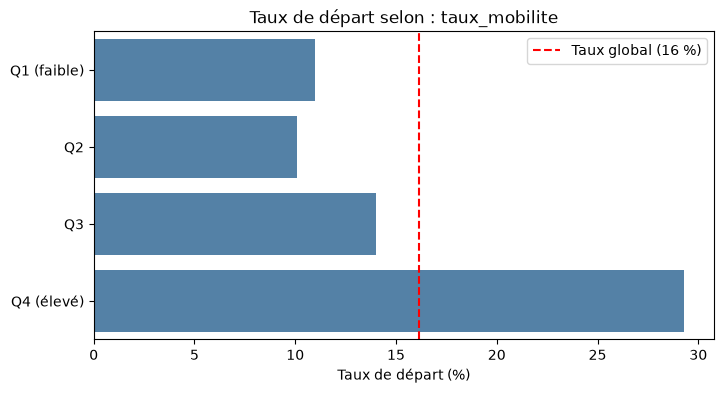

,Effectif,Départs,Taux de départ (%)
age_embauche,,,
Q1 (faible),383,71,18.5
Q2,372,69,18.5
Q3,373,52,13.9
Q4 (élevé),342,45,13.2


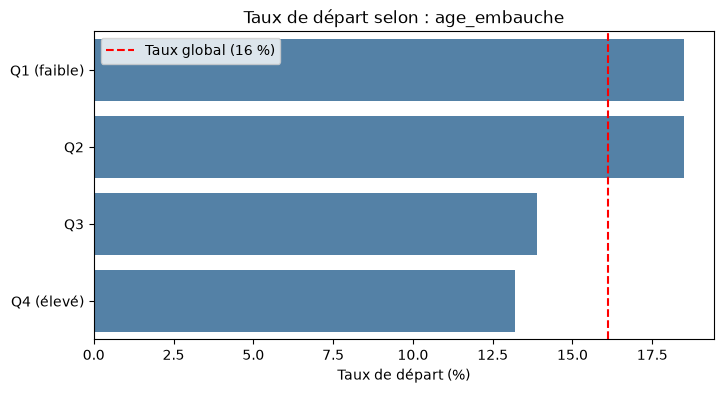

,Effectif,Départs,Taux de départ (%)
nb_satisfactions_a_1,,,
0,733,81,11.1
1,574,105,18.3
2,135,39,28.9
3,27,11,40.7
4,1,1,100.0


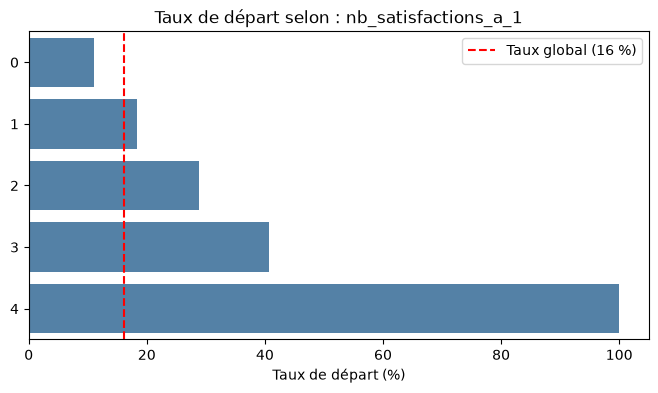

In [108]:
# ------------------------------------------------------------
# Vérification : les features candidates sont-elles liées au départ ?
# ------------------------------------------------------------
# Variables continues : découpage en 4 groupes de même effectif (quartiles)
quartiles = ["Q1 (faible)", "Q2", "Q3", "Q4 (élevé)"]
for col in ["taux_mobilite", "age_embauche"]:
    df_test = df_candidates.assign(**{col: pd.qcut(df_candidates[col], q=4, labels=quartiles)})
    taux_depart_par_groupe(df_test, col, trier_par_taux=False)

# Variable déjà discrète (0 à 4) : pas besoin de découpage
taux_depart_par_groupe(df_candidates, "nb_satisfactions_a_1", trier_par_taux=False)

In [109]:
# Redondance de age_embauche avec l'âge ?
print("Corrélation âge / âge à l'embauche :", round(df_candidates["age"].corr(df_candidates["age_embauche"]), 2))

Corrélation âge / âge à l'embauche : 0.78


**Conclusions** (attention : l'échelle de l'axe varie d'un graphique à l'autre, on compare les chiffres)
- `taux_mobilite` : **29 %** de départs pour le quart le plus mobile, contre 10-11 % pour les moins mobiles - **retenue**
- `nb_satisfactions_a_1` : progression régulière de **11 %** (aucune note à 1) à **41 %** (3 notes à 1) - **retenue** (la valeur 4 ne concerne qu'une personne)
- `age_embauche` : écart faible (13 à 18,5 %) et forte corrélation avec l'âge (0,78) - **hypothèse écartée**

#### 4.4.2 Fonction de création des features retenues

In [110]:
# ------------------------------------------------------------
# Fonction : création des features retenues
# ------------------------------------------------------------
def ajouter_features(df):
    """Crée les features retenues en 4.4.1 et renvoie une copie enrichie du DataFrame."""
    df = df.copy()   # on travaille sur une copie pour ne pas modifier le DataFrame reçu

    # 1) Taux de mobilité : nombre d'entreprises précédentes par année d'expérience
    df["taux_mobilite"] = df["nombre_experiences_precedentes"] / (df["annee_experience_totale"] + 1)

    # 2) Nombre de dimensions de satisfaction notées 1 (très insatisfait)
    df["nb_satisfactions_a_1"] = (df[COLONNES_SATISFACTION] == 1).sum(axis=1)

    return df

df_modele = ajouter_features(df_modele)
print(df_modele.shape)   # attendu : 1470 lignes, 27 colonnes (25 + 2 features)

(1470, 27)


### 4.5 Encodage des variables qualitatives
Le modèle n'accepte que des nombres : chaque variable texte est encodée selon son sens métier.

In [111]:
# ------------------------------------------------------------
# Variables texte restantes et leurs valeurs
# ------------------------------------------------------------
for col in df_modele.select_dtypes(exclude="number").columns:
    print(f"{col} ({df_modele[col].nunique()} valeurs) : {sorted(df_modele[col].unique())}")

genre (2 valeurs) : ['F', 'M']
statut_marital (3 valeurs) : ['Célibataire', 'Divorcé(e)', 'Marié(e)']
poste (9 valeurs) : ['Assistant de Direction', 'Cadre Commercial', 'Consultant', 'Directeur Technique', 'Manager', 'Représentant Commercial', 'Ressources Humaines', 'Senior Manager', 'Tech Lead']
domaine_etude (6 valeurs) : ['Autre', 'Entrepreunariat', 'Infra & Cloud', 'Marketing', 'Ressources Humaines', 'Transformation Digitale']
frequence_deplacement (3 valeurs) : ['Aucun', 'Frequent', 'Occasionnel']


| Colonne | Nature | Encodage |
|---|---|---|
| `genre` | Binaire | 0/1 |
| `frequence_deplacement` | Ordonnée (Aucun < Occasionnel < Frequent) | Ordinal 0 / 1 / 2 |
| `statut_marital`, `domaine_etude`, `poste` | Sans ordre | One-hot |

In [112]:
# ------------------------------------------------------------
# Fonction : encodage des variables qualitatives
# ------------------------------------------------------------
COLONNES_ONE_HOT = ["statut_marital", "domaine_etude", "poste"]
ORDRE_DEPLACEMENT = {"Aucun": 0, "Occasionnel": 1, "Frequent": 2}

def encoder_variables(df):
    """Encode les variables texte en nombres et renvoie une copie du DataFrame."""
    df = df.copy()

    # 1) Genre : variable binaire -> une seule colonne 0/1
    #    On renomme la colonne pour que le 1 ait un sens explicite
    df["genre"] = df["genre"].map({"F": 0, "M": 1})
    df = df.rename(columns={"genre": "genre_masculin"})

    # 2) Fréquence de déplacement : variable ordonnée -> encodage ordinal
    df["frequence_deplacement"] = df["frequence_deplacement"].map(ORDRE_DEPLACEMENT)

    # 3) Variables sans ordre -> one-hot : une colonne 0/1 par valeur possible
    #    dtype=int : des 0/1 plutôt que des True/False
    df = pd.get_dummies(df, columns=COLONNES_ONE_HOT, dtype=int)

    return df

df_encode = encoder_variables(df_modele)

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------
# 1) Dimensions : 27 - 3 (colonnes sources) + 3 + 6 + 9 (colonnes one-hot) = 42
print("Dimensions :", df_encode.shape)

# 2) Il ne doit plus rester aucune colonne texte
print("Colonnes non numériques :", list(df_encode.select_dtypes(exclude="number").columns))

# 3) Aucune valeur vide : .map() renvoie une case vide si une valeur n'est pas dans le dictionnaire
#    (une faute d'orthographe dans ORDRE_DEPLACEMENT serait donc détectée ici)
print("Valeurs manquantes :", df_encode.isna().sum().sum())

# 4) Aperçu des colonnes créées par le one-hot
display(df_encode.filter(like="poste_").head())

Dimensions : (1470, 42)
Colonnes non numériques : []
Valeurs manquantes : 0


,annees_dans_le_poste_actuel,poste_Assistant de Direction,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead
0,4,0,1,0,0,0,0,0,0,0
1,7,1,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0,0
4,2,0,0,1,0,0,0,0,0,0


### 4.6 Fonction de préparation complète
Assemblage de toutes les transformations validées (4.3 à 4.5) en une seule fonction, applicable au fichier central ou à de nouvelles données de même structure.

In [115]:
# ------------------------------------------------------------
# Fonction finale : du DataFrame central à X (features) et y (cible)
# ------------------------------------------------------------
def preparer_donnees(df):
    """Applique toutes les transformations de l'étape 2 et renvoie X (features) et y (cible)."""
    # 1) Suppression des variables redondantes (4.3)
    df = df.drop(columns=COLONNES_REDONDANTES)

    # 2) Création des features retenues (4.4)
    df = ajouter_features(df)

    # 3) Encodage des variables texte (4.5)
    df = encoder_variables(df)

    # 4) Séparation de la cible et des features
    #    id_employee est retiré : un numéro d'identifiant n'explique rien
    y = df["a_quitte_l_entreprise"]
    X = df.drop(columns=["a_quitte_l_entreprise", "id_employee"])

    return X, y

X, y = preparer_donnees(df)

In [116]:
# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------
# 1) Dimensions : X = 42 colonnes - cible - identifiant = 40 features
print("X :", X.shape)
print("y :", y.shape)

# 2) La cible doit avoir la même répartition qu'au départ (1 233 restés / 237 partis)
display(y.value_counts())

# 3) X doit être entièrement numérique et sans valeur manquante (condition pour fit())
print("Colonnes non numériques :", list(X.select_dtypes(exclude="number").columns))
print("Valeurs manquantes :", X.isna().sum().sum())

# 4) La fonction doit donner exactement le même résultat que les étapes faites une par une
print("Identique au pas à pas :", X.equals(df_encode.drop(columns=["a_quitte_l_entreprise", "id_employee"])))

X : (1470, 40)
y : (1470,)


a_quitte_l_entreprise
0    1233
1     237
Name: count, dtype: int64

Colonnes non numériques : []
Valeurs manquantes : 0
Identique au pas à pas : True


**Synthèse de la préparation des données**
- **4 variables retirées** pour redondance : `niveau_hierarchique_poste` (doublon du revenu), `annees_sous_responsable_actuel` (doublon de l'ancienneté), `note_evaluation_actuelle` (déterminée par l'augmentation), `departement` (déterminé par le poste)
- **2 features créées** après test : `taux_mobilite` et `nb_satisfactions_a_1` ; `age_embauche` testée puis écartée
- **Encodage** selon le sens métier : binaire (genre), ordinal (fréquence de déplacement), one-hot (statut marital, domaine d'étude, poste)
- **Résultat** : `X` (1 470 × 40 features numériques, sans valeur manquante) et `y` (cible, 16 % de départs), produits par la fonction `preparer_donnees(df)`
- **Standardisation** reportée après la séparation train / test, pour éviter toute fuite de données